***All necessary imports***

In [29]:
import pandas as pd
import sys
import os
import numpy as np
from torch.nn.functional import threshold

%reload_ext autoreload
%autoreload 2
%matplotlib inline
modules_path = os.path.abspath("../modules")
if modules_path not in sys.path:
    sys.path.append(modules_path)
from helper_functions import HelperFunctions

***Create dataframe and remove duplicates***

In [2]:
bank_df = pd.read_csv('../csv/bank-additional-full.csv', sep=';')
bank_df = bank_df[~bank_df.duplicated()]

***Create ydata report and show dataframe info***

In [3]:
HelperFunctions.write_ydata_report_to_file(bank_df, "../html/ydata_report_initial.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

***[ydata initial report can be found here](https://reserford1991.github.io/bank-marketing-dataset-project/html/ydata_report_initial.html)***

In [4]:
bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
bank_df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null  floa

In [6]:
bank_df.isnull().values.any()

False

Let's transform strring columns into category columns

In [7]:
bank_df = HelperFunctions.transform_string_into_category_type(bank_df, ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'y'])

bank_df.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41176 non-null  int64   
 1   job             41176 non-null  category
 2   marital         41176 non-null  category
 3   education       41176 non-null  category
 4   default         41176 non-null  category
 5   housing         41176 non-null  category
 6   loan            41176 non-null  category
 7   contact         41176 non-null  category
 8   month           41176 non-null  category
 9   day_of_week     41176 non-null  category
 10  duration        41176 non-null  int64   
 11  campaign        41176 non-null  int64   
 12  pdays           41176 non-null  int64   
 13  previous        41176 non-null  int64   
 14  poutcome        41176 non-null  object  
 15  emp.var.rate    41176 non-null  float64 
 16  cons.price.idx  41176 non-null  float64 
 17  cons.conf.idx   4

***As we can see, there are 20 feature columns and one target column - y.***

***Dataset has no null values in columns.***

***There are 10 categorical columns and 10 numeric columns.***

***Let's investigate each of those columns***

***1. `age` column analysis***

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64
Number of null values: 0


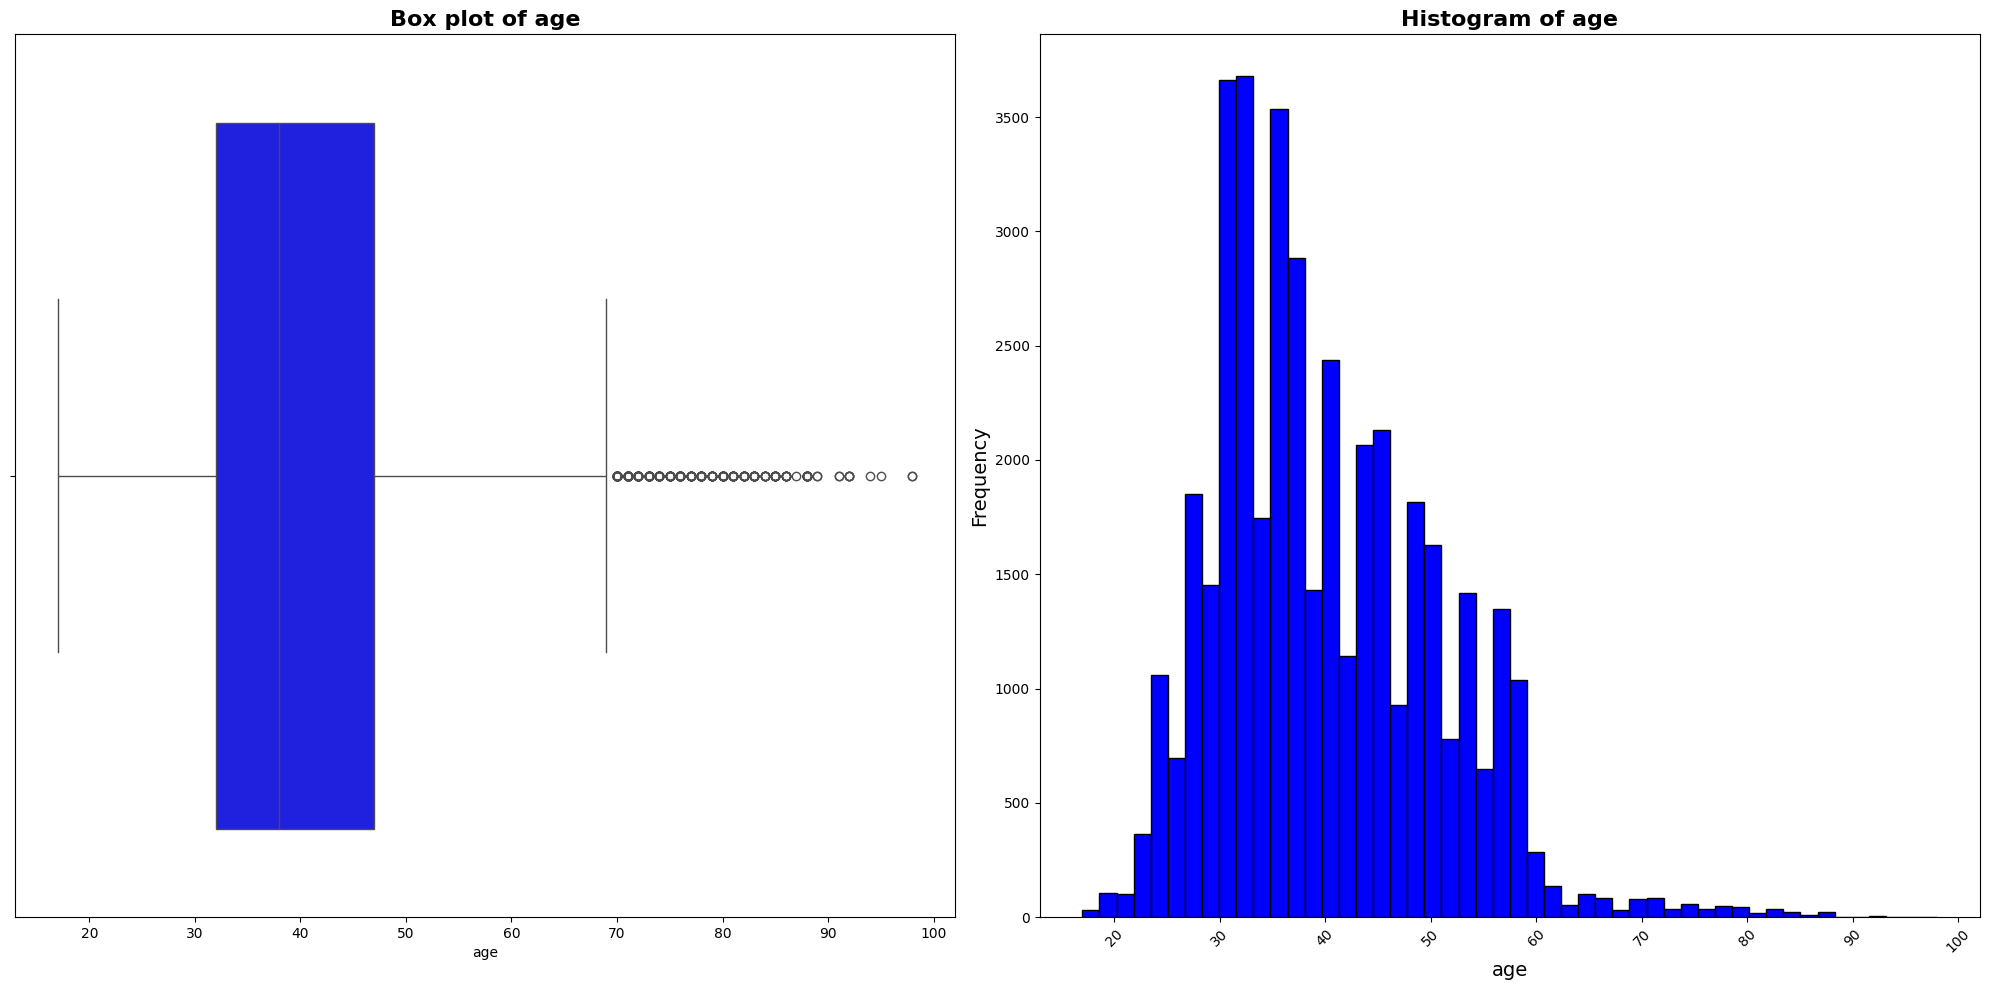

In [8]:
HelperFunctions.show_numeric_info(bank_df, 'age', 50)

As we can see, data can be considered normally distributed, if not the ages above 60.
But don't want to remove those ages, because it may reduce model accuracy and besides that, model which did ton train on data with ages above 60 can make wrong decisions.

***2. `job` column analysis***

count      41176
unique        12
top       admin.
freq       10419
Name: job, dtype: object
Number of null values: 0


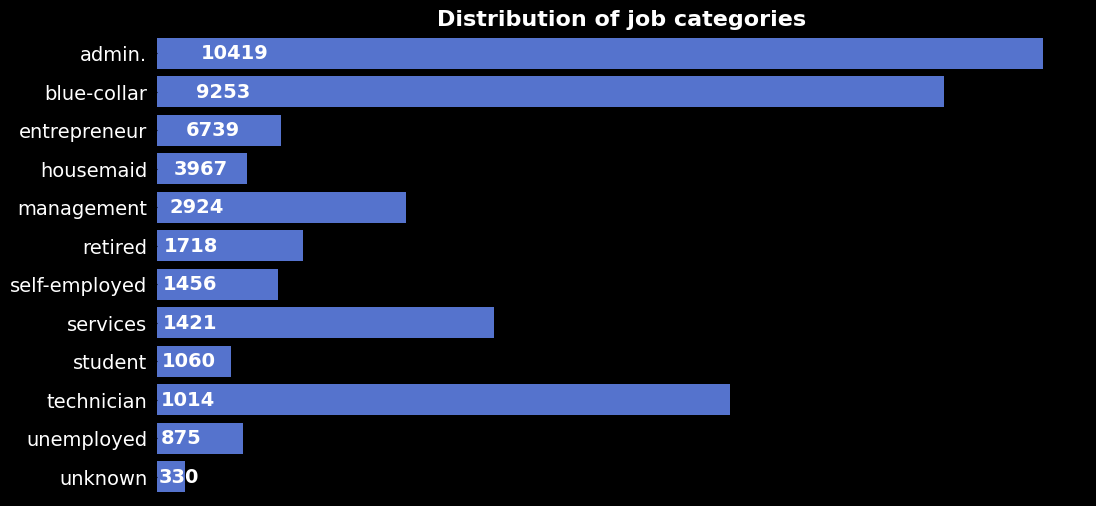

category


In [9]:
HelperFunctions.show_categorical_info(bank_df, 'job')

Here we can see, that there are not so many 'unknown' job types, so I would impute 'unknown' with mode value.

count      41176
unique        11
top       admin.
freq       10749
Name: job, dtype: object
Number of null values: 0


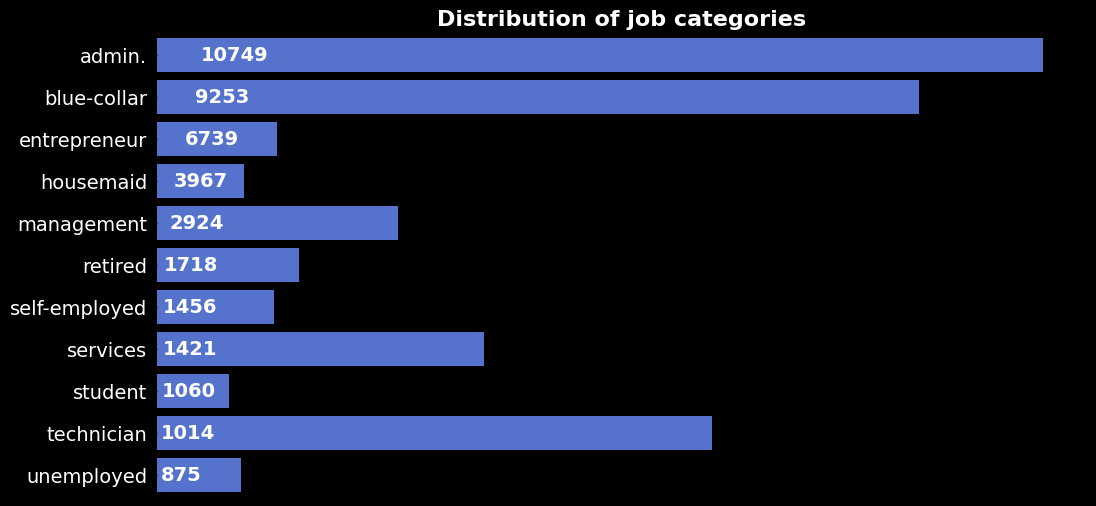

category


In [10]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'job', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'job')

***3. `marital` column analysis***

count       41176
unique          4
top       married
freq        24921
Name: marital, dtype: object
Number of null values: 0


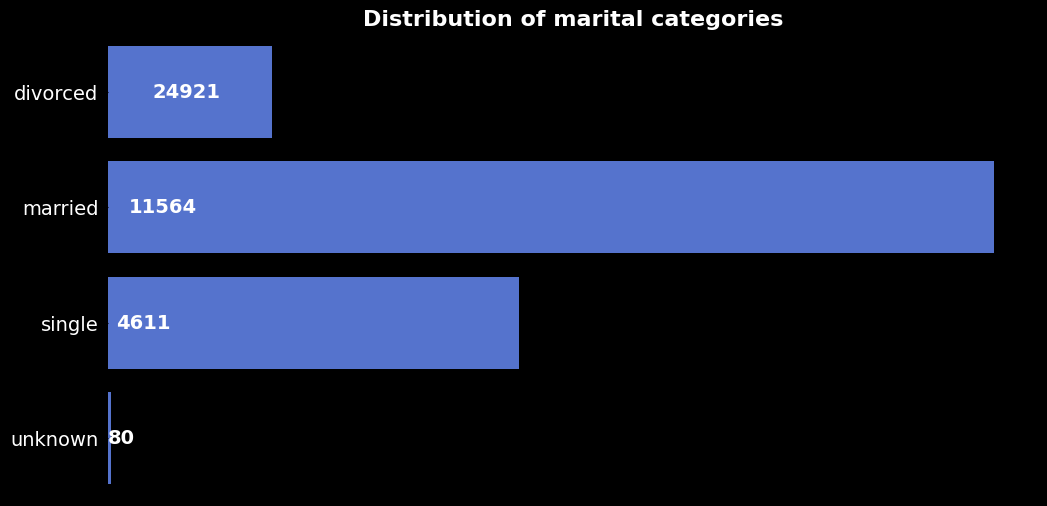

category


In [11]:
HelperFunctions.show_categorical_info(bank_df, 'marital')

Here also can se not so many 'unknown' marital status. So I would impute it wit most frequent category of a column.

count       41176
unique          3
top       married
freq        25001
Name: marital, dtype: object
Number of null values: 0


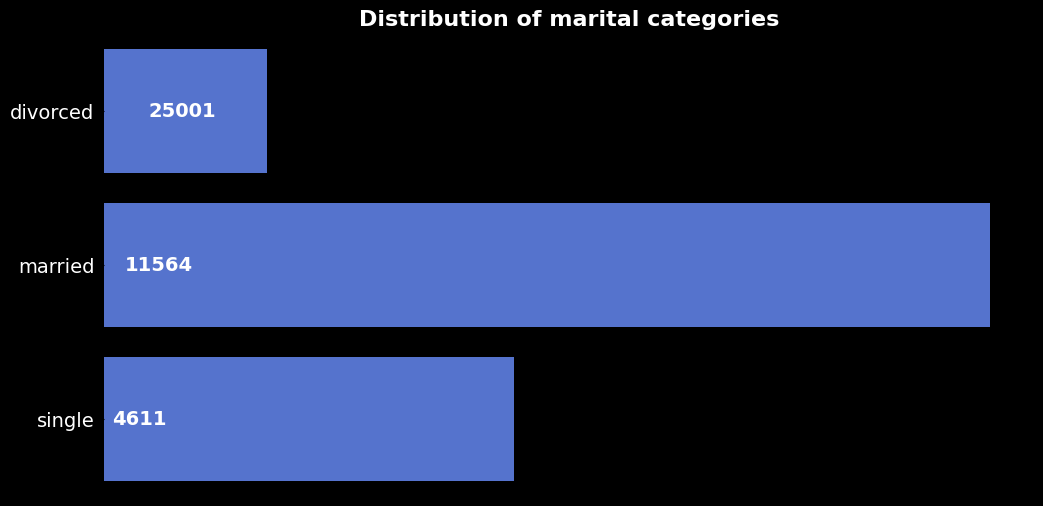

category


In [12]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'marital', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'marital')

***4. `education` column analysis***

count                 41176
unique                    8
top       university.degree
freq                  12164
Name: education, dtype: object
Number of null values: 0


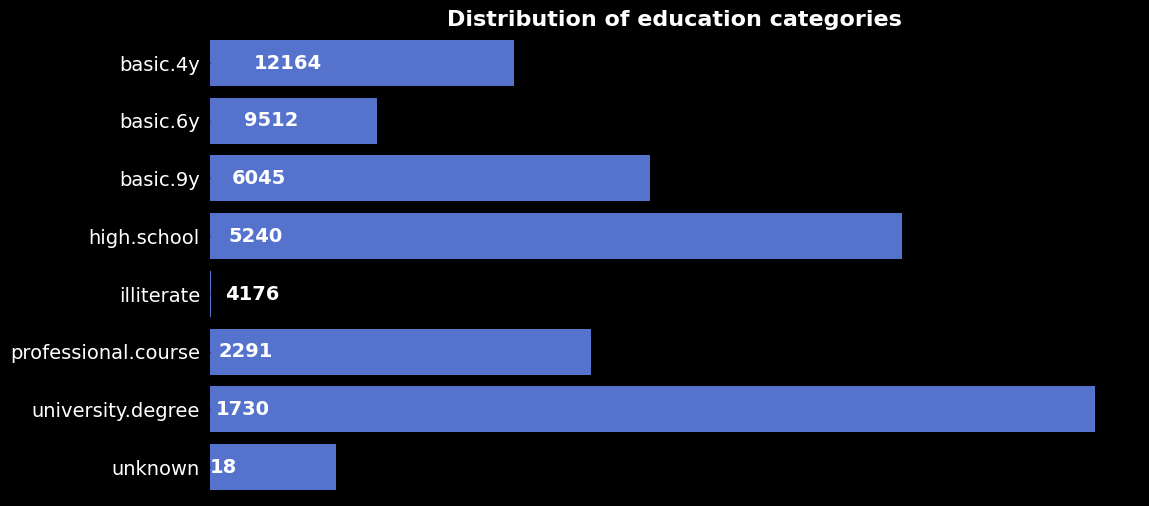

category


In [13]:
HelperFunctions.show_categorical_info(bank_df, 'education')

Here I see a little bit of unknown and no missing values, so imputation changes needed.

count                 41176
unique                    7
top       university.degree
freq                  13894
Name: education, dtype: object
Number of null values: 0


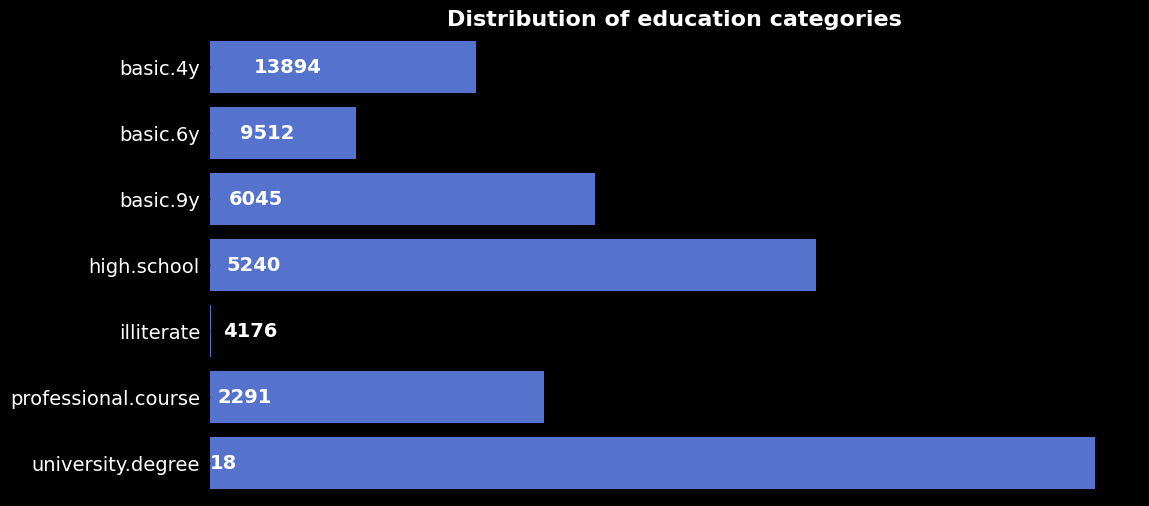

category


In [14]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'education', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'education')

***5. `default` column analysis***

count     41176
unique        3
top          no
freq      32577
Name: default, dtype: object
Number of null values: 0


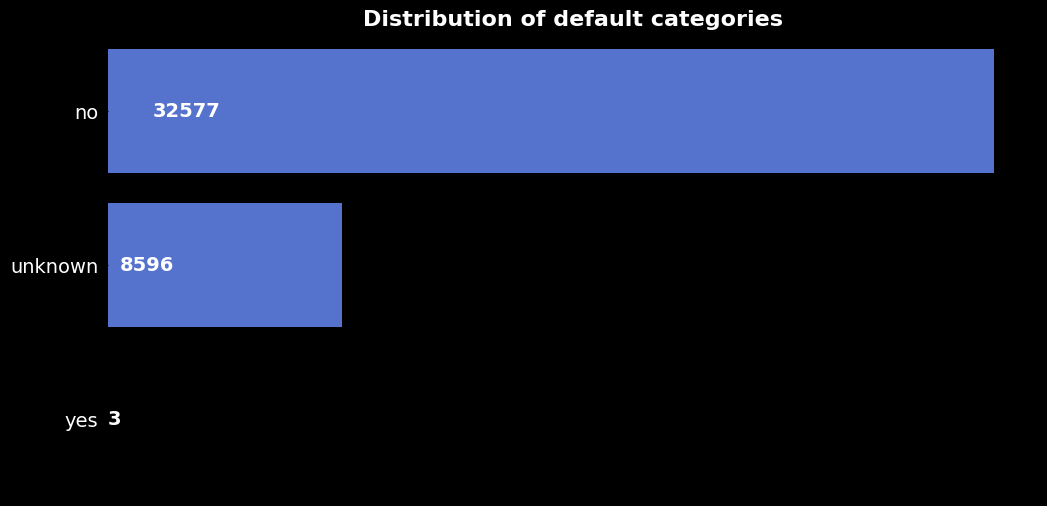

category


In [15]:
HelperFunctions.show_categorical_info(bank_df, 'default')

We can see there are many unknown rows. So I'll just transform this column into category type instead string to save memory as I don't sure whether should I transform unknown into yes or no.

count     41176
unique        3
top          no
freq      32577
Name: default, dtype: object
Number of null values: 0


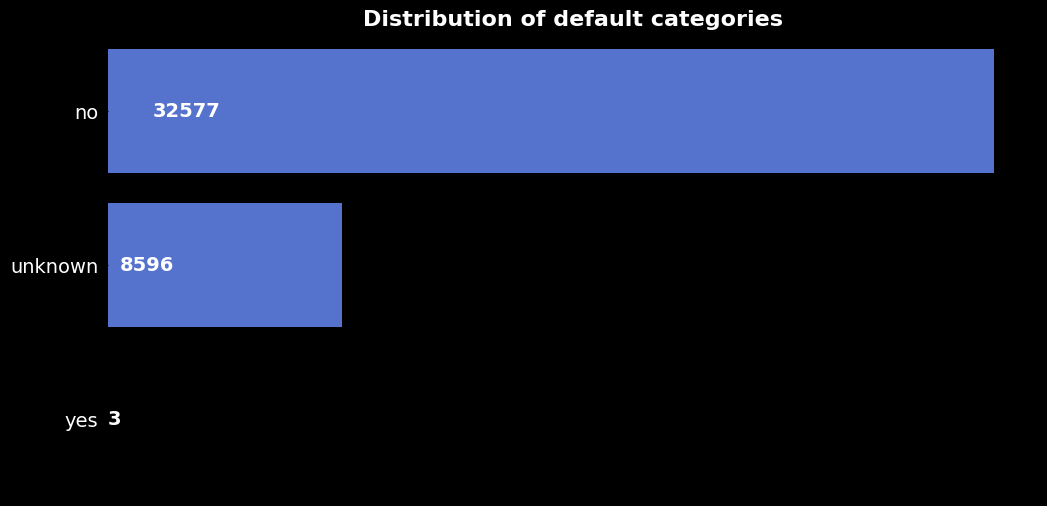

category


In [16]:
HelperFunctions.show_categorical_info(bank_df, 'default')

***6. `housing` column analysis***

count     41176
unique        3
top         yes
freq      21571
Name: housing, dtype: object
Number of null values: 0


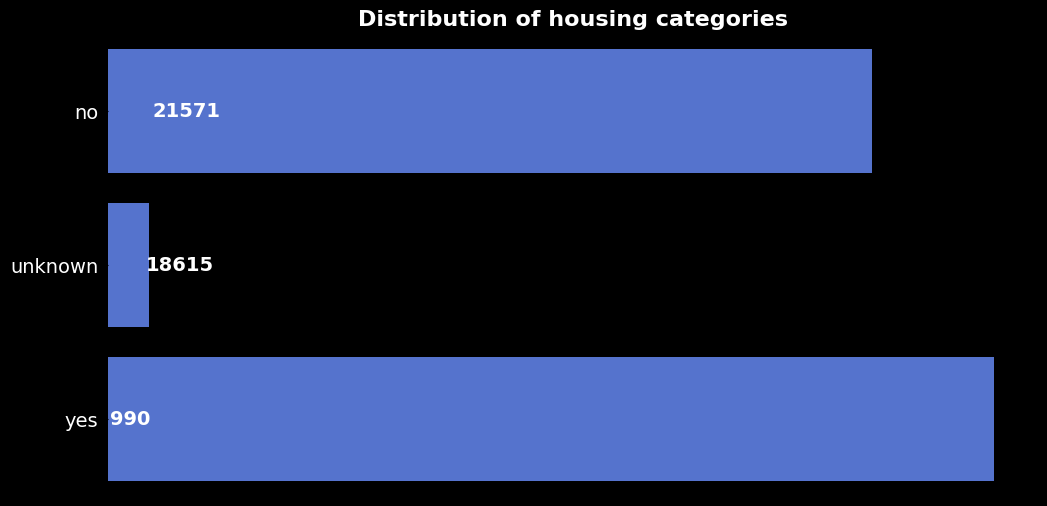

category


In [17]:
HelperFunctions.show_categorical_info(bank_df, 'housing')

Lets impute unknown with mode value here.

count     41176
unique        2
top         yes
freq      22561
Name: housing, dtype: object
Number of null values: 0


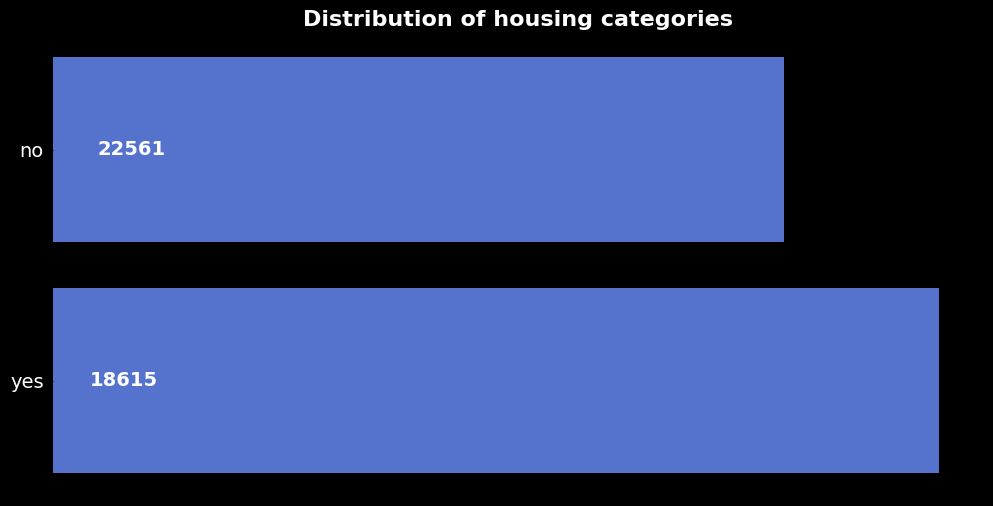

category


In [18]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'housing', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'housing')

***7. `loan` column analysis***

count     41176
unique        3
top          no
freq      33938
Name: loan, dtype: object
Number of null values: 0


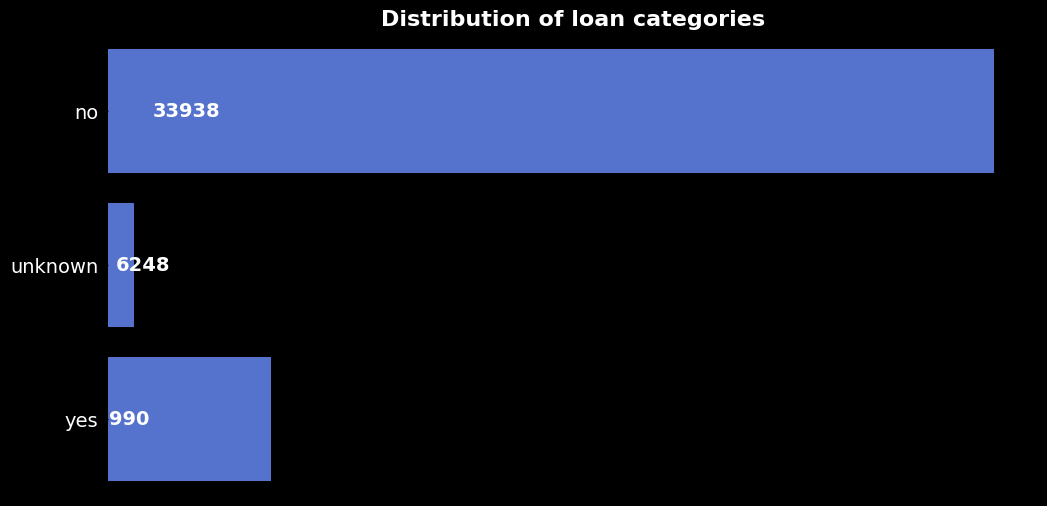

category


In [21]:
HelperFunctions.show_categorical_info(bank_df, 'loan')

I think it will be good idea to impute unknown values with mode here.

count     41176
unique        2
top         yes
freq      22561
Name: housing, dtype: object
Number of null values: 0


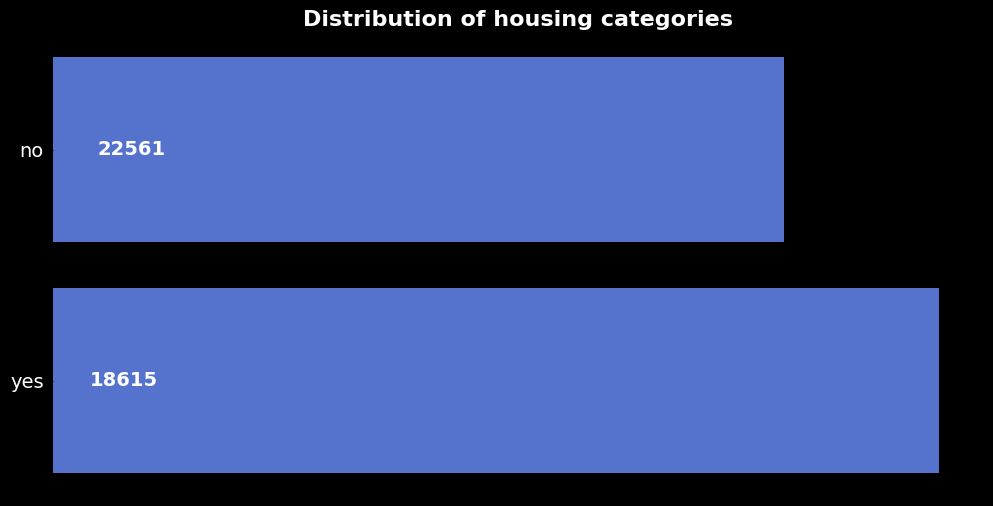

category


In [22]:
bank_df = HelperFunctions.impute_categorical_unknown_values(bank_df, 'housing', 'mode')
HelperFunctions.show_categorical_info(bank_df, 'housing')

***8. `contact` column analysis***

count        41176
unique           2
top       cellular
freq         26135
Name: contact, dtype: object
Number of null values: 0


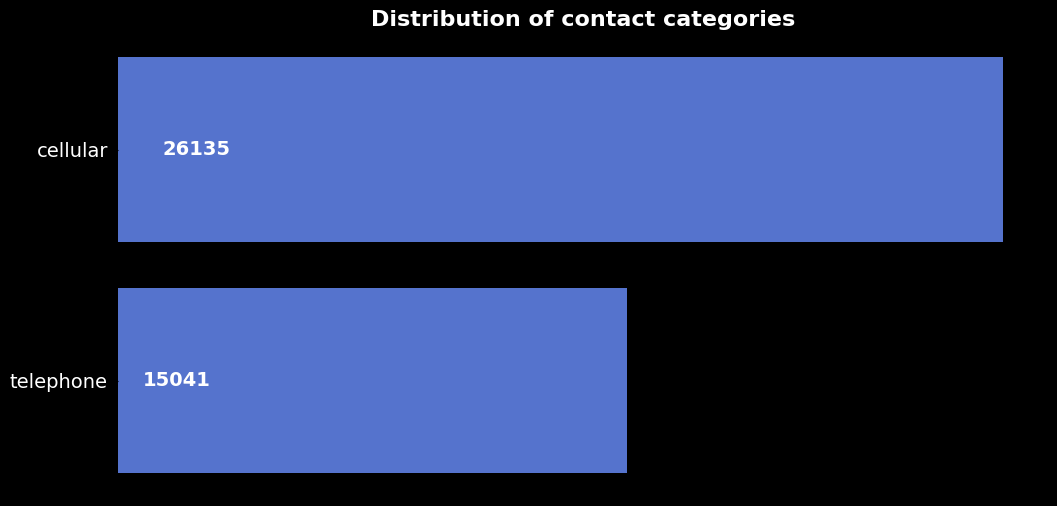

category


In [23]:
HelperFunctions.show_categorical_info(bank_df, 'contact')

No imputations are needed here

***9. `month` column analysis***

count     41176
unique       10
top         may
freq      13767
Name: month, dtype: object
Number of null values: 0


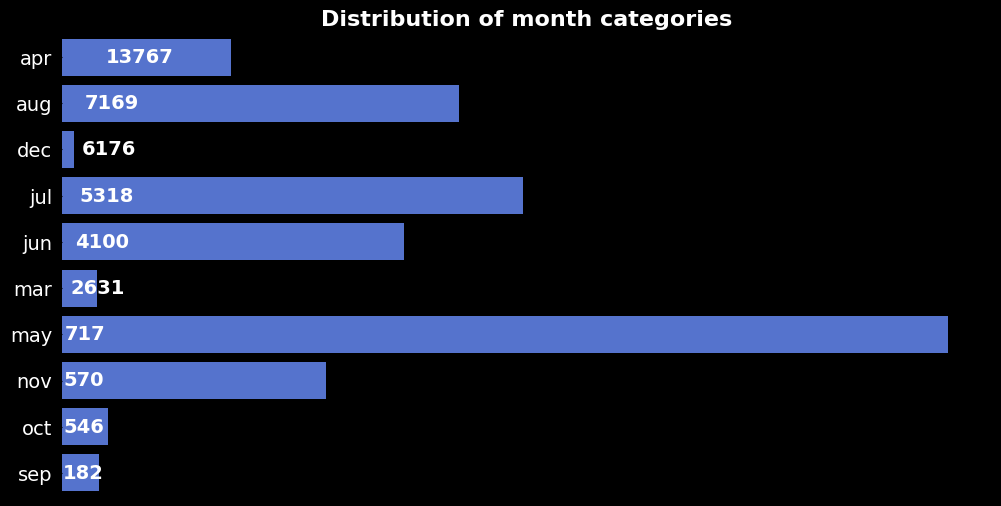

category


In [25]:
HelperFunctions.show_categorical_info(bank_df, 'month')

No imputations are needed here

***10. `day_of_week` column analysis***

count     41176
unique        5
top         thu
freq       8618
Name: day_of_week, dtype: object
Number of null values: 0


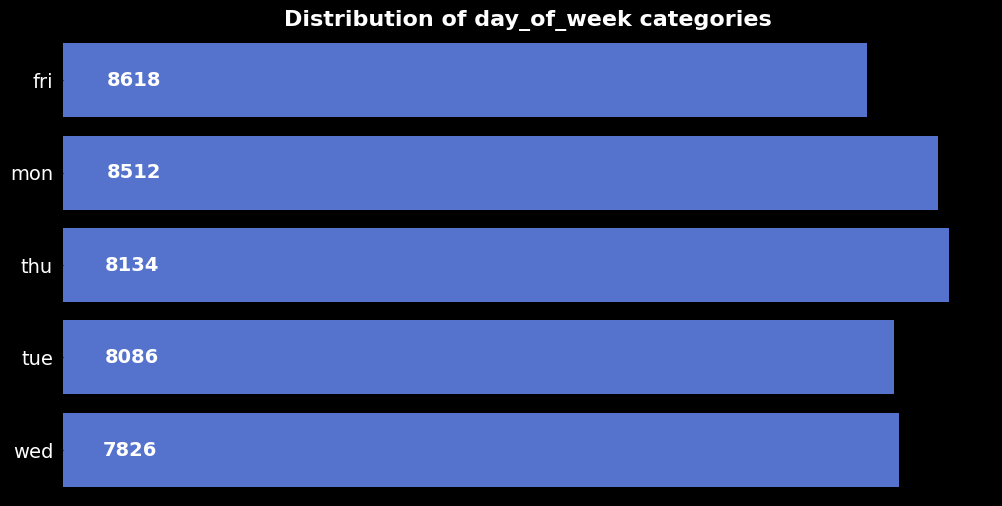

category


In [26]:
HelperFunctions.show_categorical_info(bank_df, 'day_of_week')

No imputations are needed here

***11. `duration` column analysis***

As we can see from from columns description - duration should be removed from dataframe. So I will do as instruction says.

In [27]:
bank_df = bank_df.drop(columns=['duration'])

bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


***12. `campaign` column analysis***

count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64
Number of null values: 0


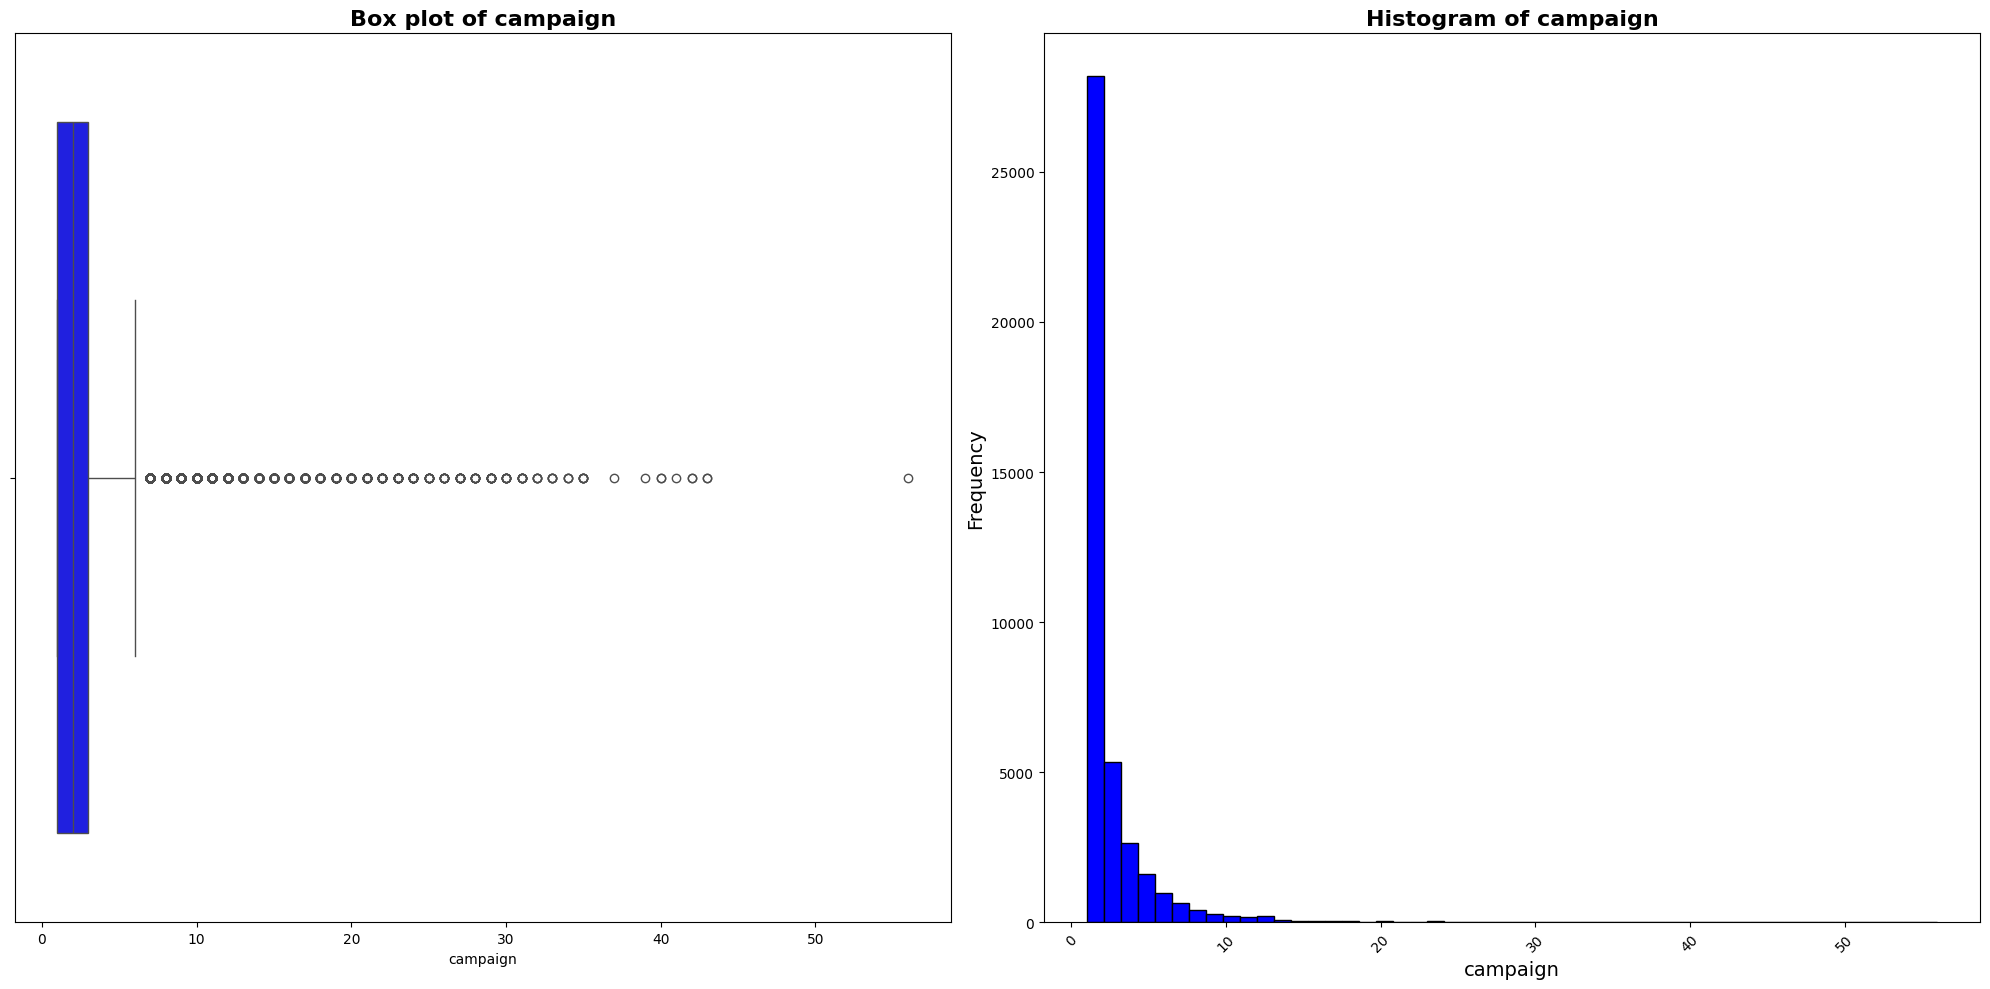

In [28]:
HelperFunctions.show_numeric_info(bank_df, 'campaign', 50)

As we can see, this column has strong right-side skewing. Lets try to apply log transformation and cap values by 99 percentile.

count    41176.000000
mean         0.539423
std          0.118103
min          0.423036
25%          0.423036
50%          0.554618
75%          0.625800
max          0.962415
Name: campaign, dtype: float64
Number of null values: 0


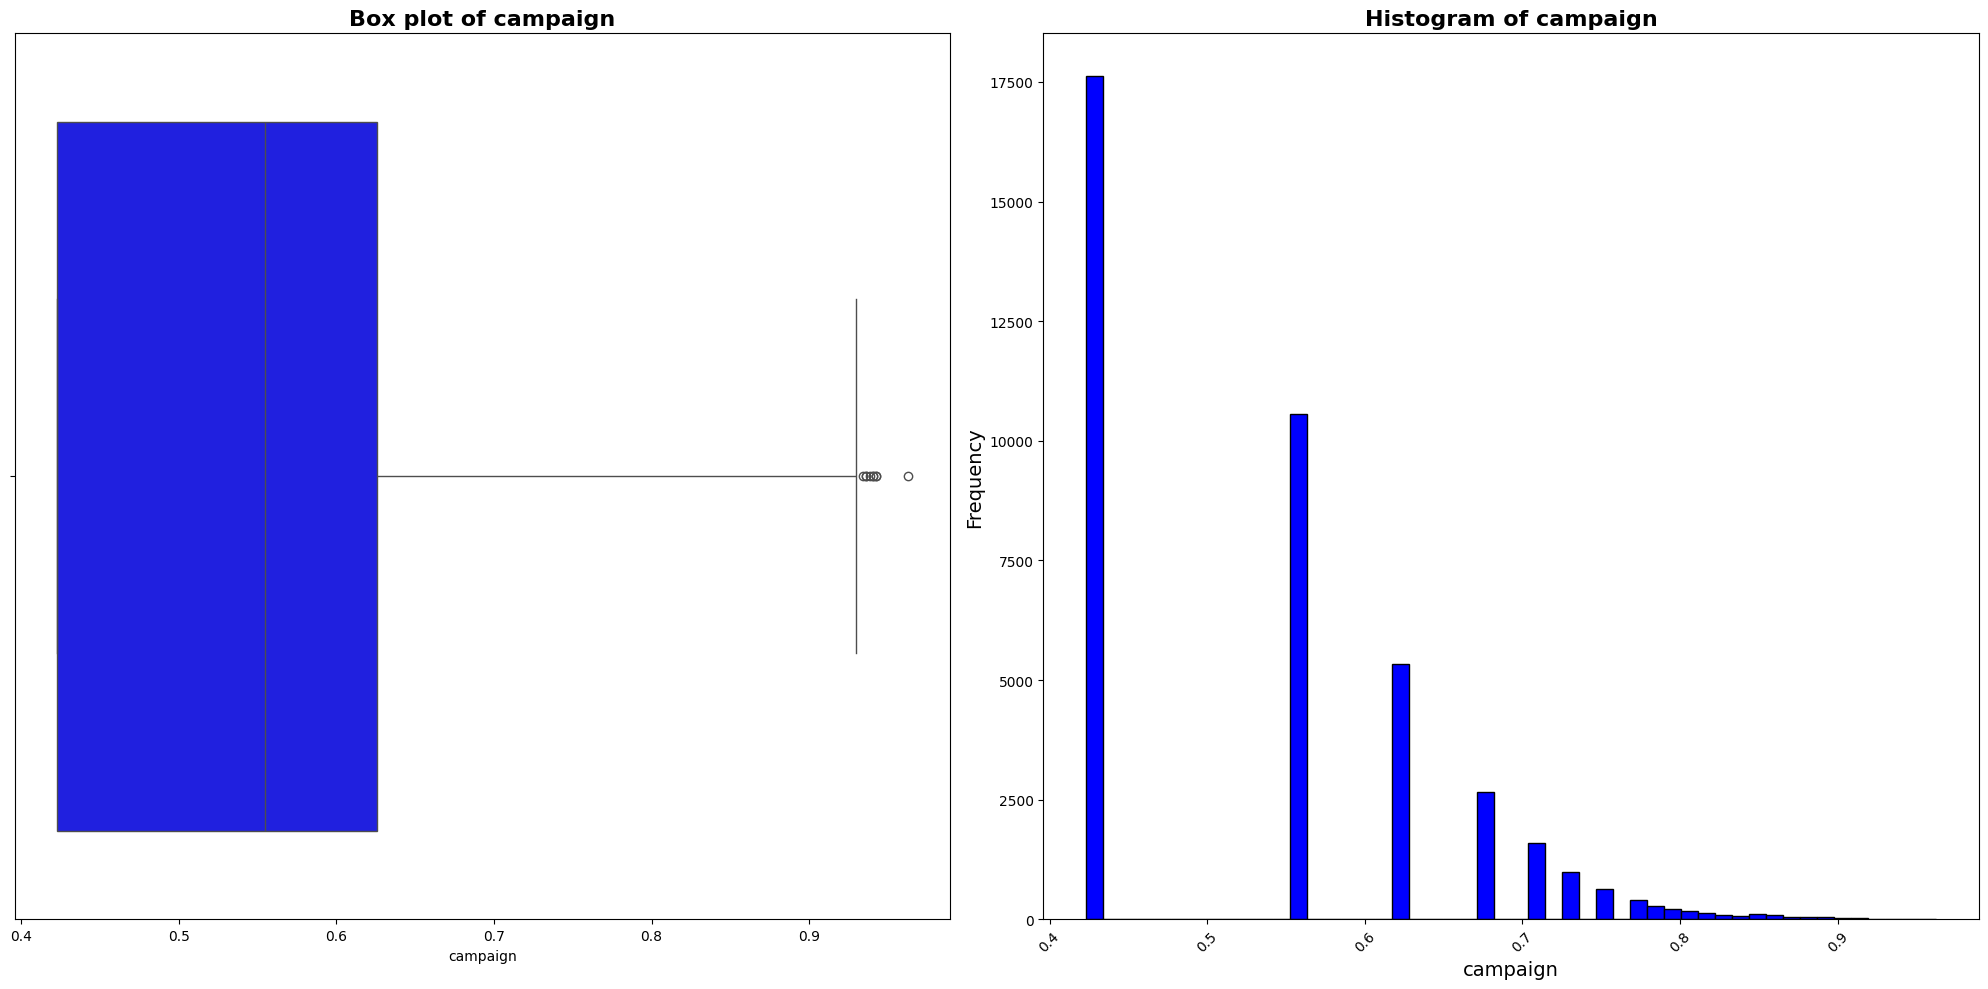

count    41176.000000
mean         0.539062
std          0.117106
min          0.423036
25%          0.423036
50%          0.554618
75%          0.625800
max          0.837467
Name: campaign_capped, dtype: float64
Number of null values: 0


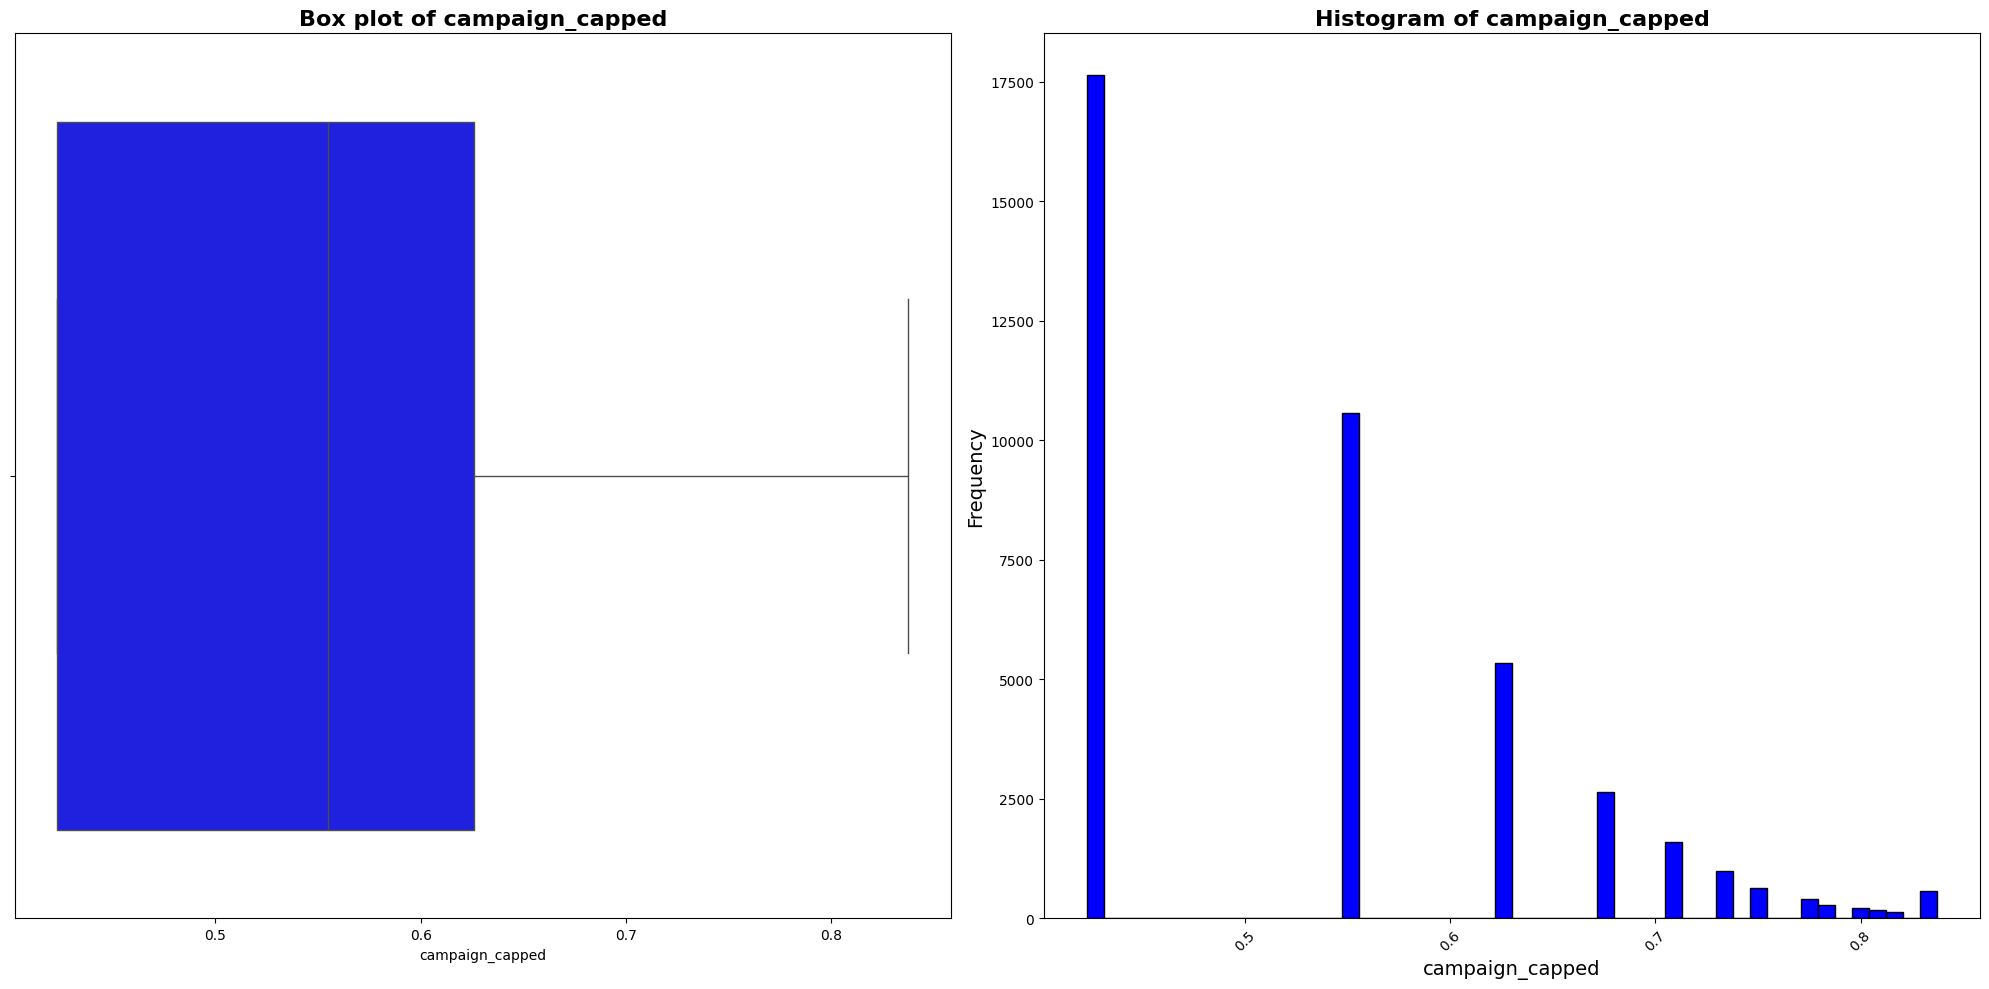

In [32]:
bank_df['campaign'] = np.log1p(bank_df['campaign'])

HelperFunctions.transform_right_skewed_numerical_column(bank_df, 'campaign')

HelperFunctions.show_numeric_info(bank_df, 'campaign', 50)
HelperFunctions.show_numeric_info(bank_df, 'campaign_capped', 50)

As we can see, new column `campaign_capped` looks better than original one. I decaded to to leave original column to be able to train model better.

***13. `pdays` column analysis***

count    41176.000000
mean       962.464810
std        186.937102
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64
Number of null values: 0


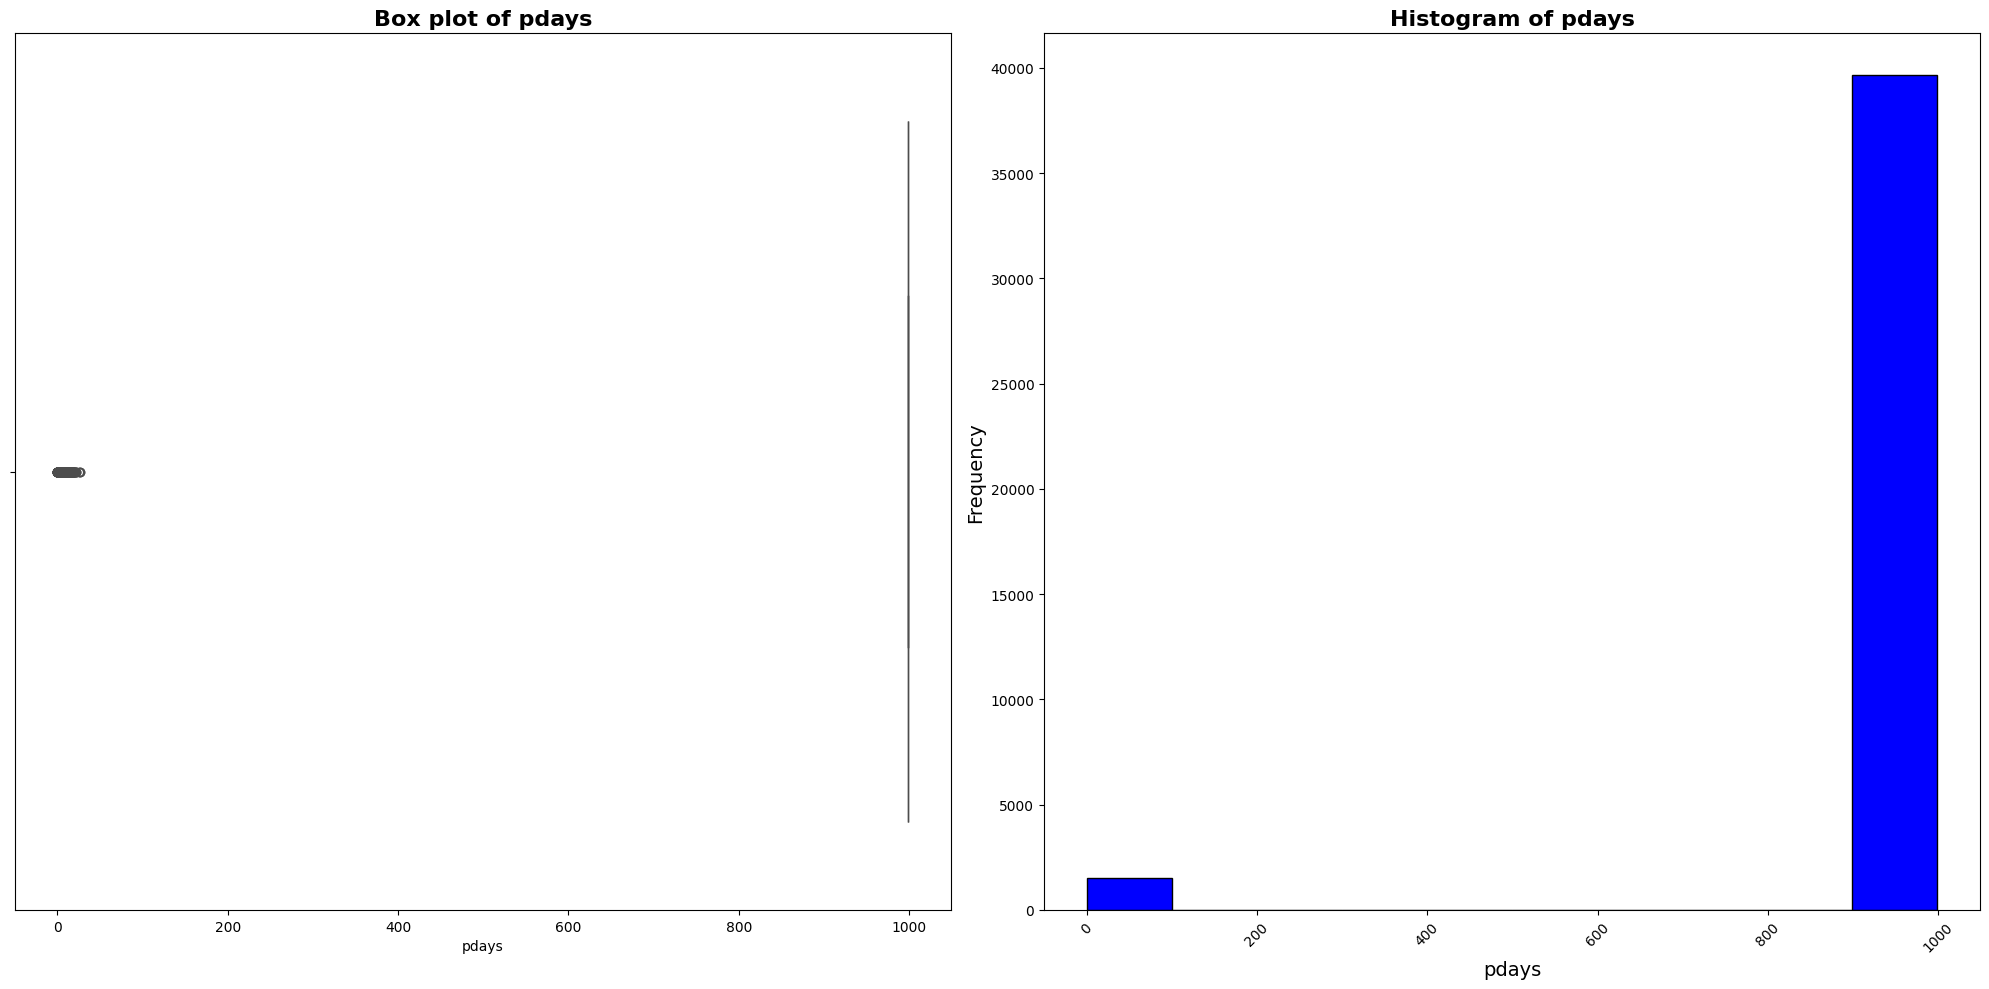

In [35]:
HelperFunctions.show_numeric_info(bank_df, 'pdays', 10)

As we can see, majoiryty of data is 999 - newver contacted and only small amount is some distinct data. So I will create new column `pdays_unknown` which will be 1 if number is 999 and 0 if it is small amount.

Besides that lets reduce skewenes a little bit by using log transfomation.

count    41176.000000
mean         0.963207
std          0.188256
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: pdays_unknown, dtype: float64
Number of null values: 0


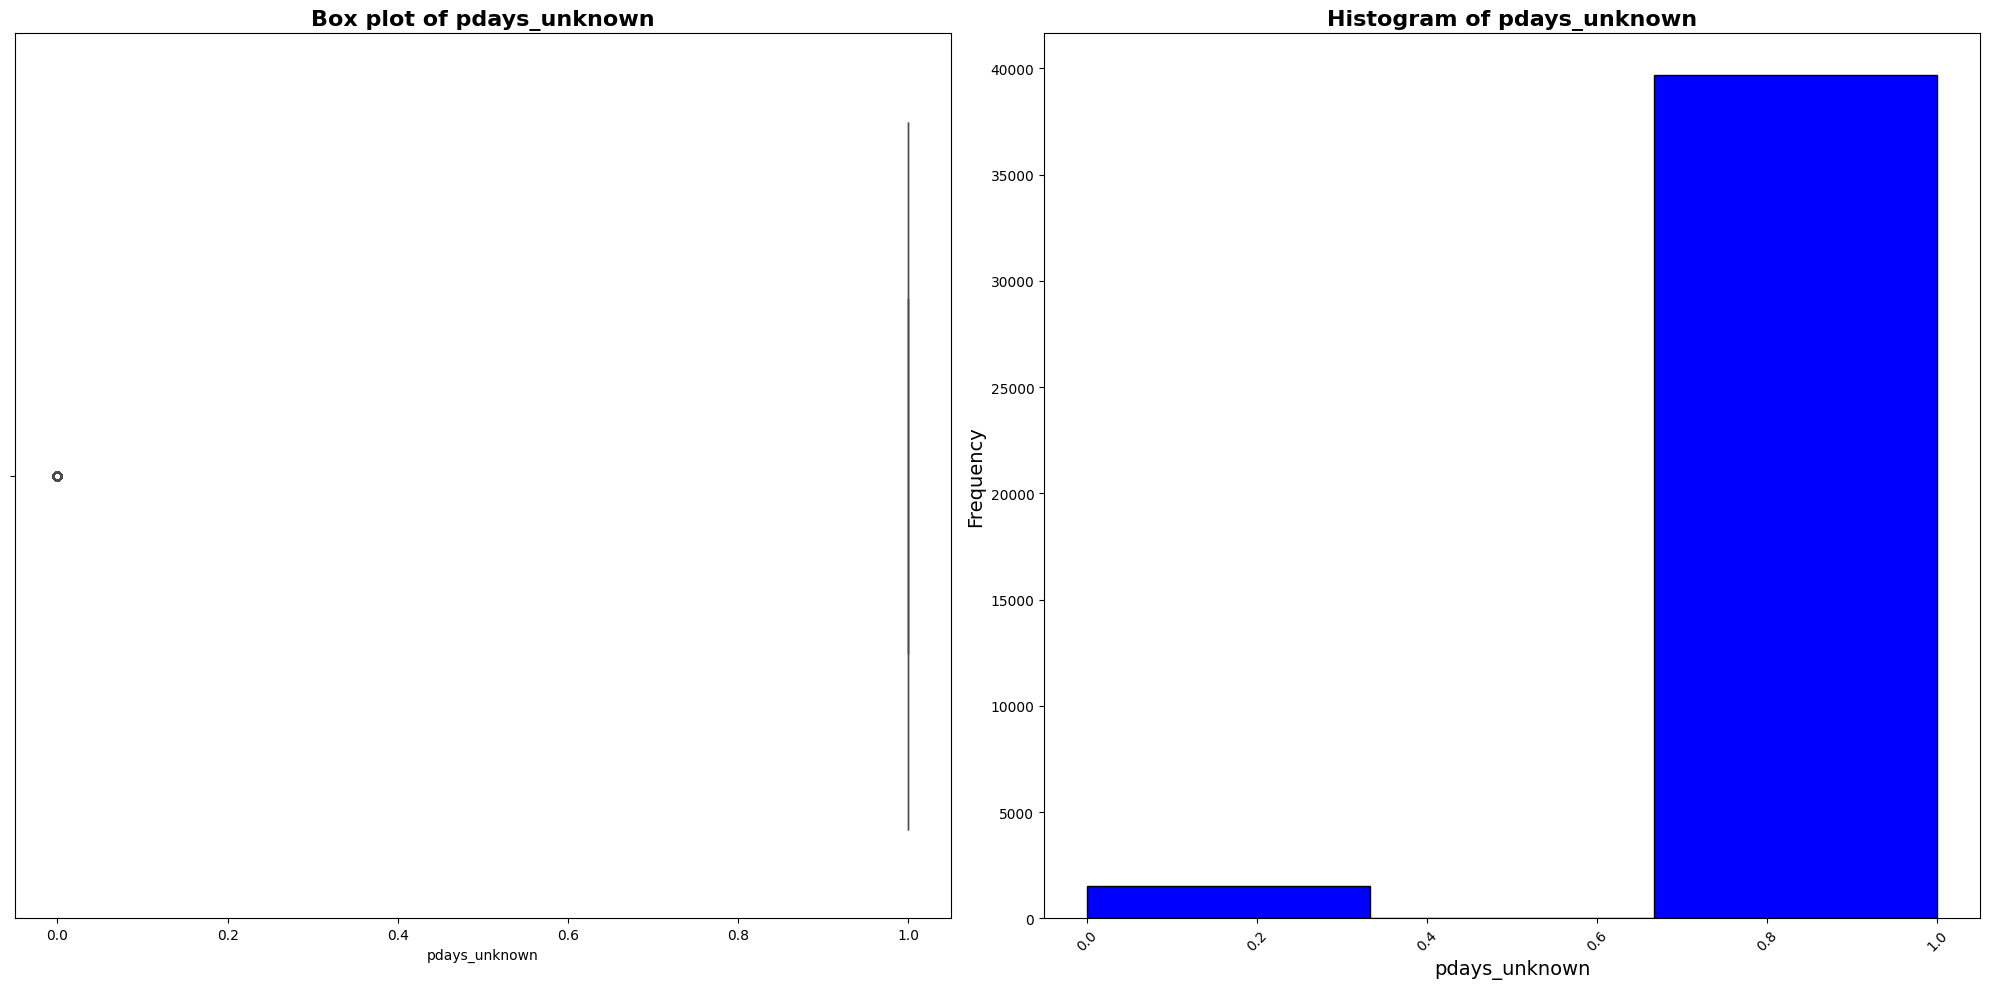

count    41176.000000
mean         6.720395
std          0.963748
min          0.000000
25%          6.907755
50%          6.907755
75%          6.907755
max          6.907755
Name: pdays_log, dtype: float64
Number of null values: 0


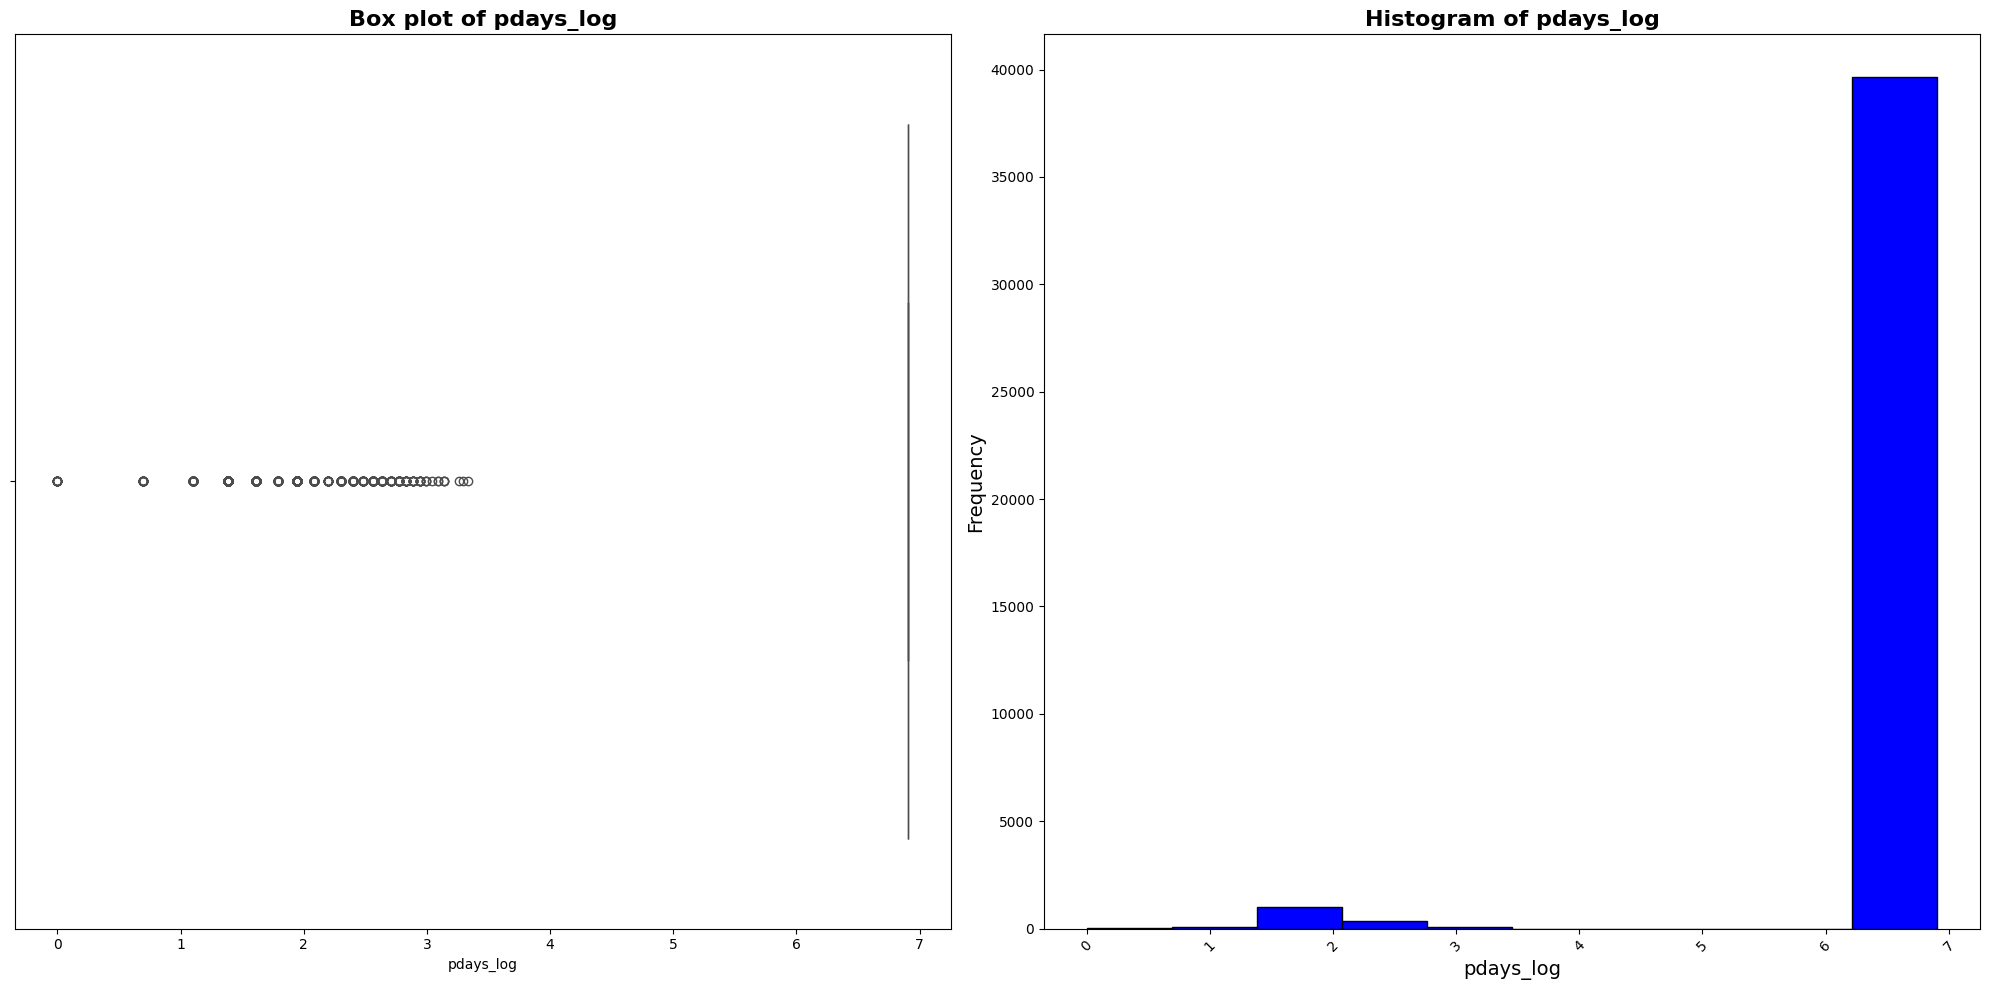

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,campaign_capped,pdays_unknown,pdays_log,previous_capped,previous_zero,previous_log
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,0.539423,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870,0.539062,0.963207,6.720395,0.162449,0.863391,0.107975
std,10.42068,0.118103,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364,0.117106,0.188256,0.963748,0.433295,0.343438,0.283049
min,17.00000,0.423036,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.423036,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32.00000,0.423036,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.423036,1.000000,6.907755,0.000000,1.000000,0.000000
50%,38.00000,0.554618,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.554618,1.000000,6.907755,0.000000,1.000000,0.000000
75%,47.00000,0.625800,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.625800,1.000000,6.907755,0.000000,1.000000,0.000000
max,98.00000,0.962415,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,0.837467,1.000000,6.907755,2.000000,1.000000,2.079442


In [43]:
bank_df['pdays_unknown'] = (bank_df['pdays'] == 999).astype(int)

bank_df["pdays_log"] = np.log1p(bank_df["pdays"])

HelperFunctions.show_numeric_info(bank_df, 'pdays_unknown', 3)
HelperFunctions.show_numeric_info(bank_df, 'pdays_log', 10)

bank_df.describe()

***14. `previous` column analysis***

count    41176.000000
mean         0.173013
std          0.494964
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64
Number of null values: 0


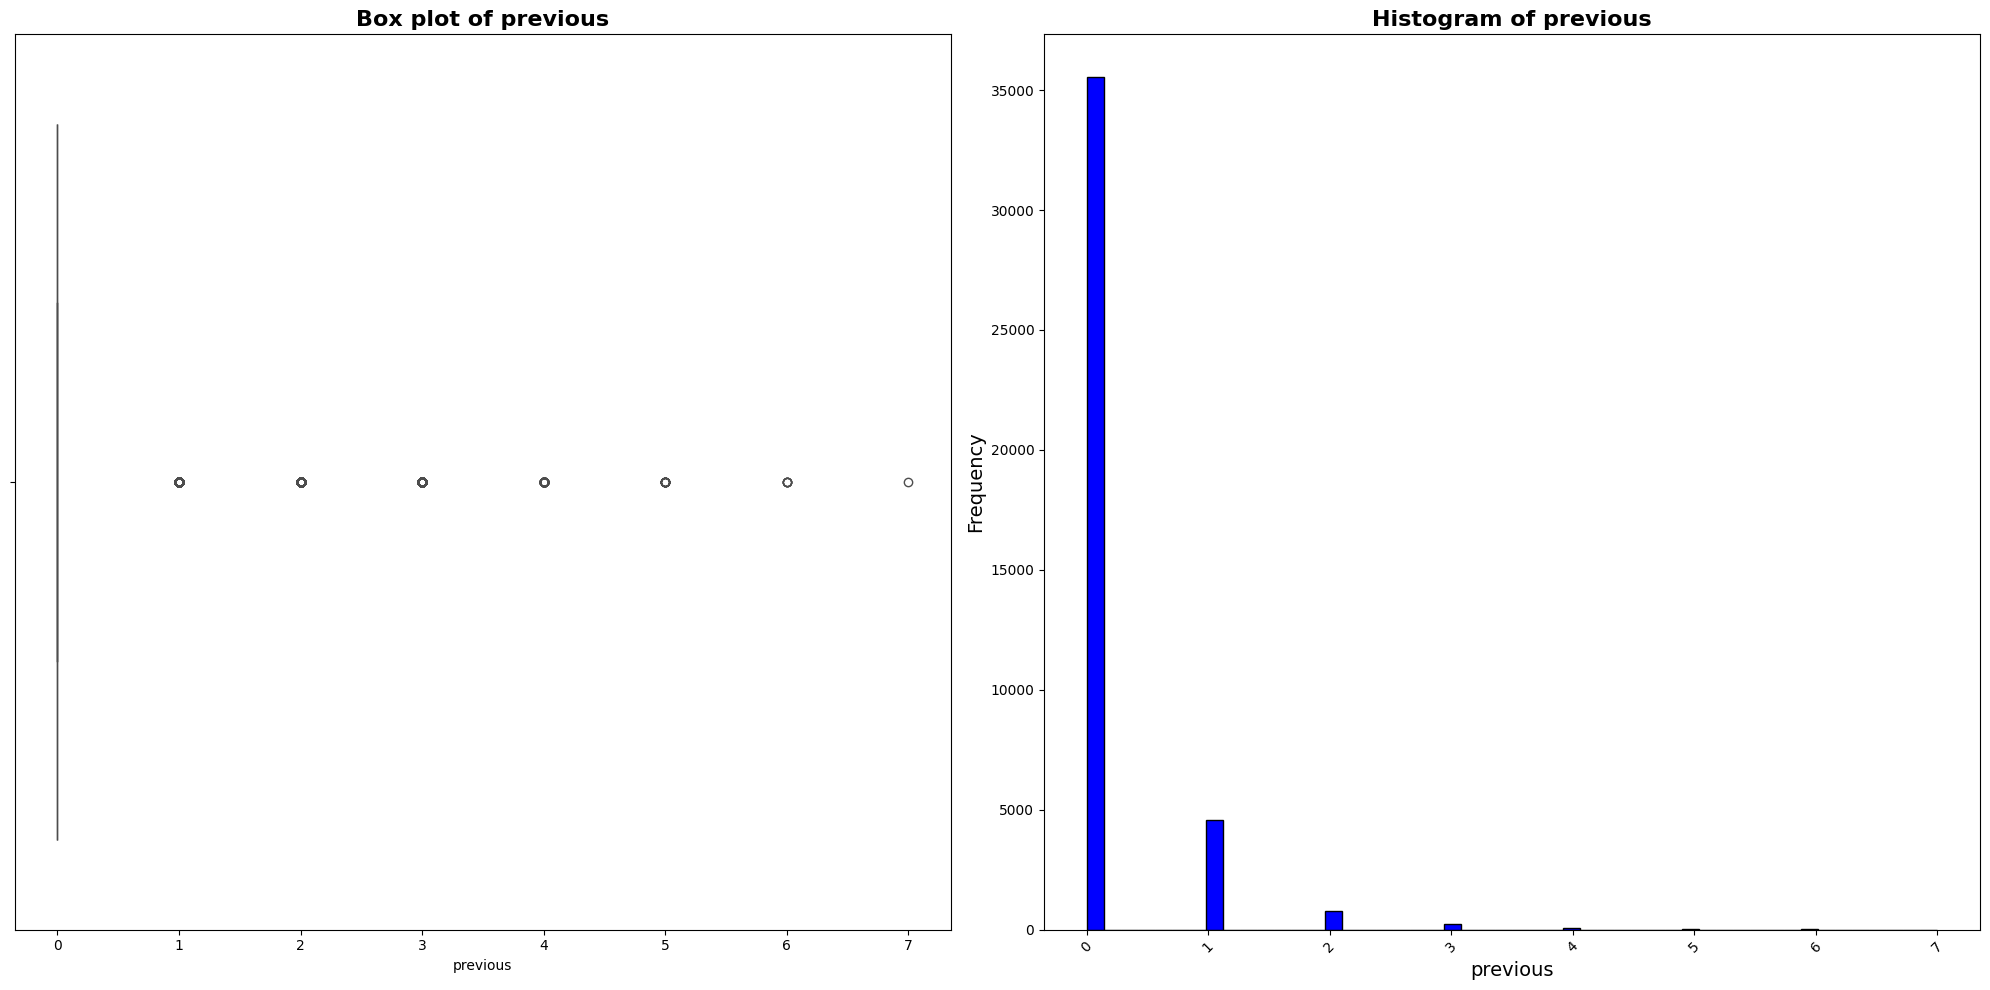

In [39]:
HelperFunctions.show_numeric_info(bank_df, 'previous', 50)

As we can see there are many records with 0 value in this column. I will create new column for that type of record. and try log

count    41176.000000
mean         0.863391
std          0.343438
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: previous_zero, dtype: float64
Number of null values: 0


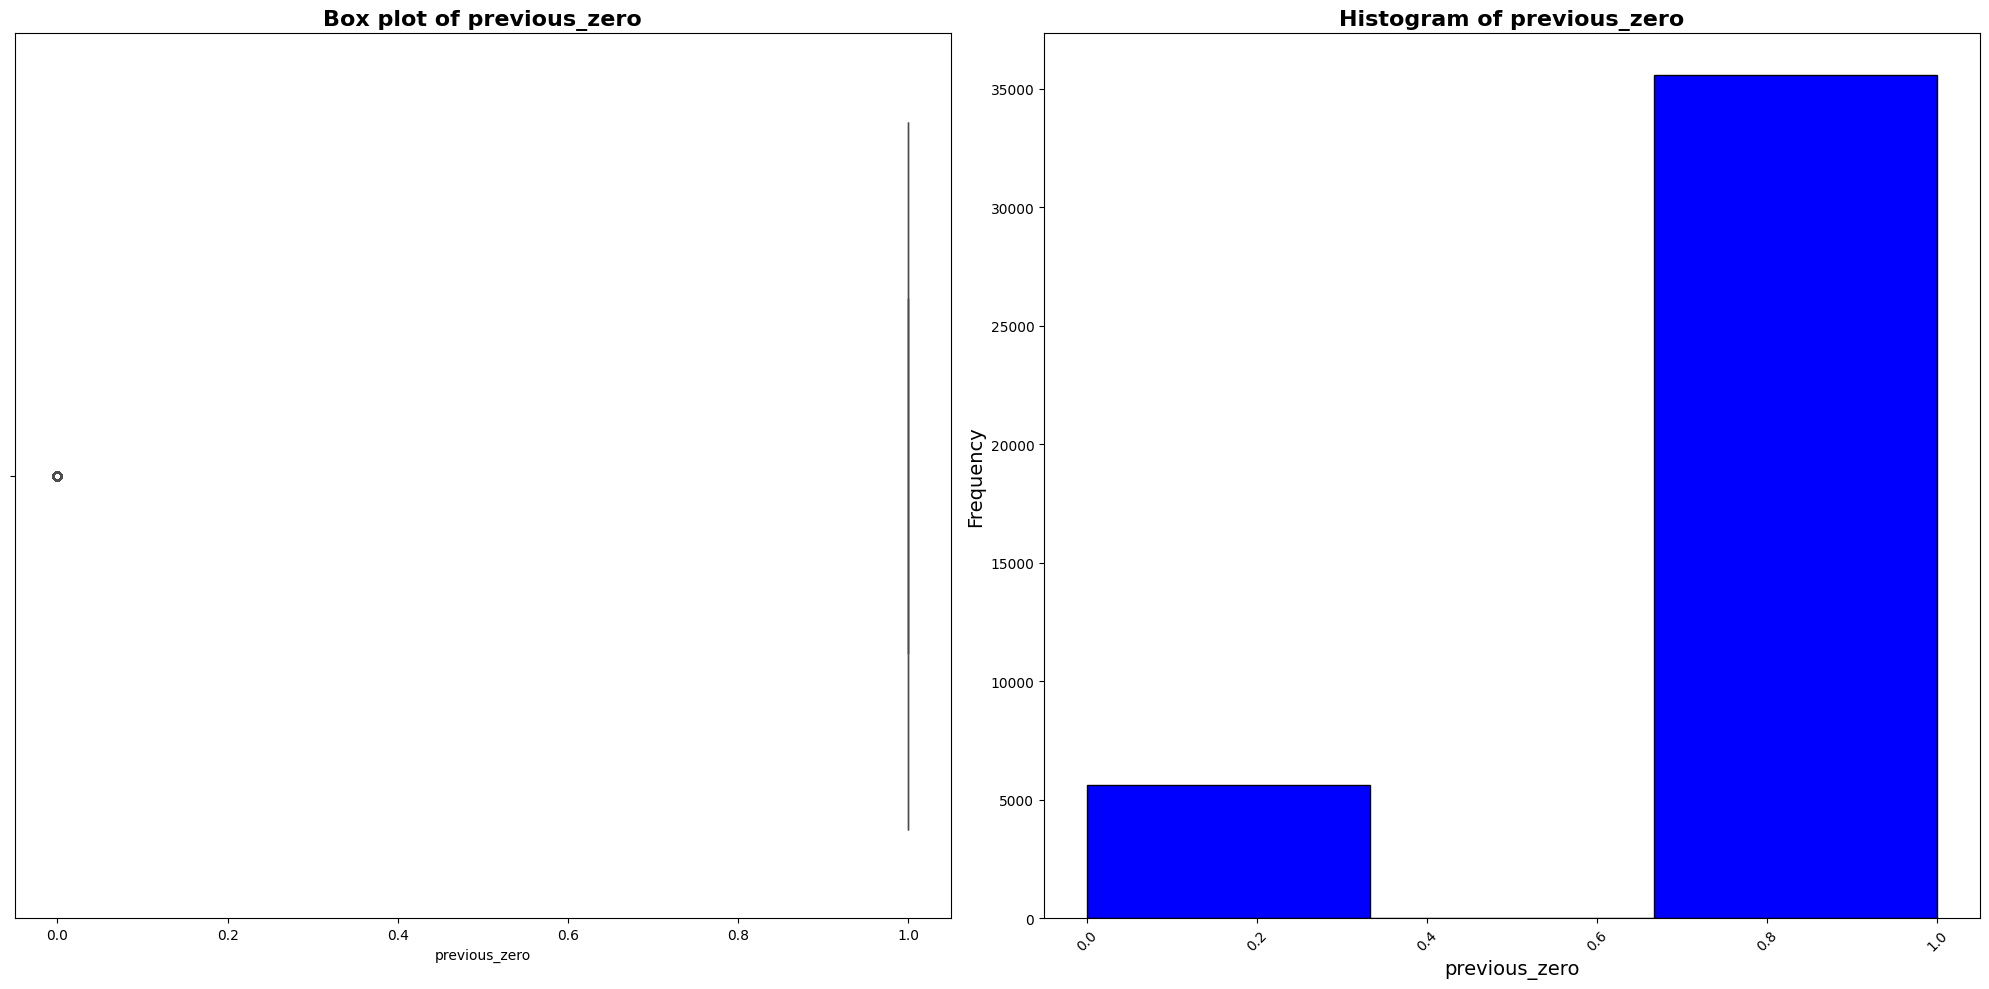

count    41176.000000
mean         0.107975
std          0.283049
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.079442
Name: previous_log, dtype: float64
Number of null values: 0


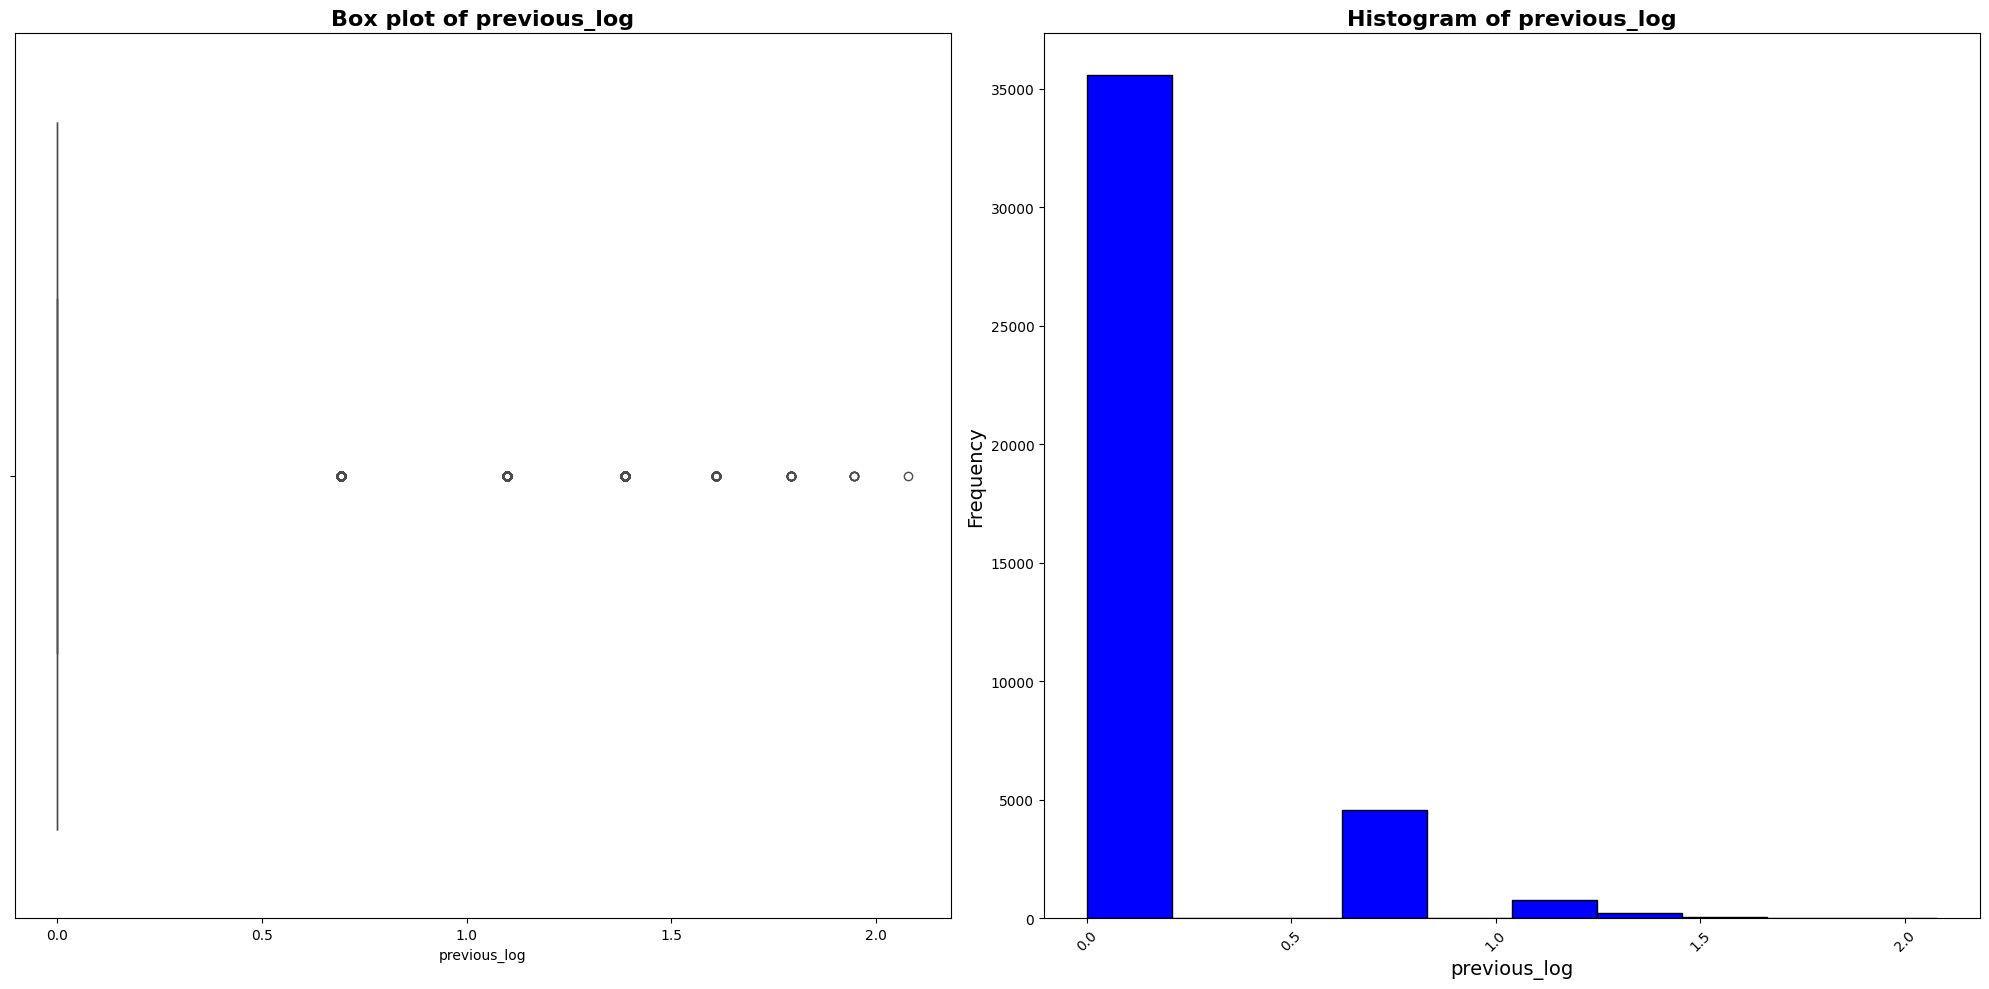

In [41]:
bank_df['previous_zero'] = (bank_df['previous'] == 0).astype(int)
bank_df["previous_log"] = np.log1p(bank_df["previous"])

HelperFunctions.show_numeric_info(bank_df, 'previous_zero', 3)
HelperFunctions.show_numeric_info(bank_df, 'previous_log', 10)

***15. `poutcome` column analysis***

count           41176
unique              3
top       nonexistent
freq            35551
Name: poutcome, dtype: object
Number of null values: 0


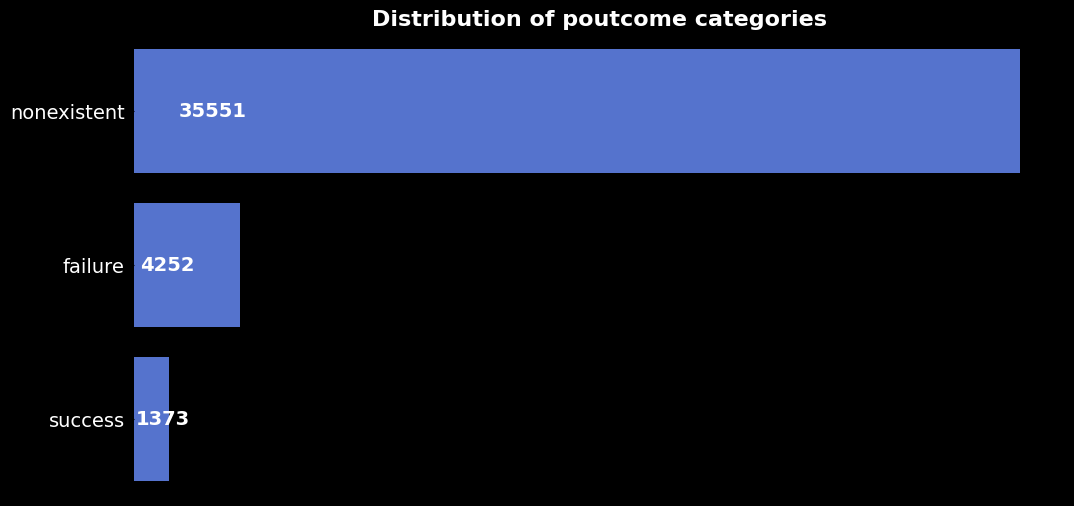

object


In [42]:
HelperFunctions.show_categorical_info(bank_df, 'poutcome')

As I can see, nonexist has quite big number of records. So I will create new columns for that.

count    41176.000000
mean         0.863391
std          0.343438
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: poutcome_nonexistent, dtype: float64
Number of null values: 0


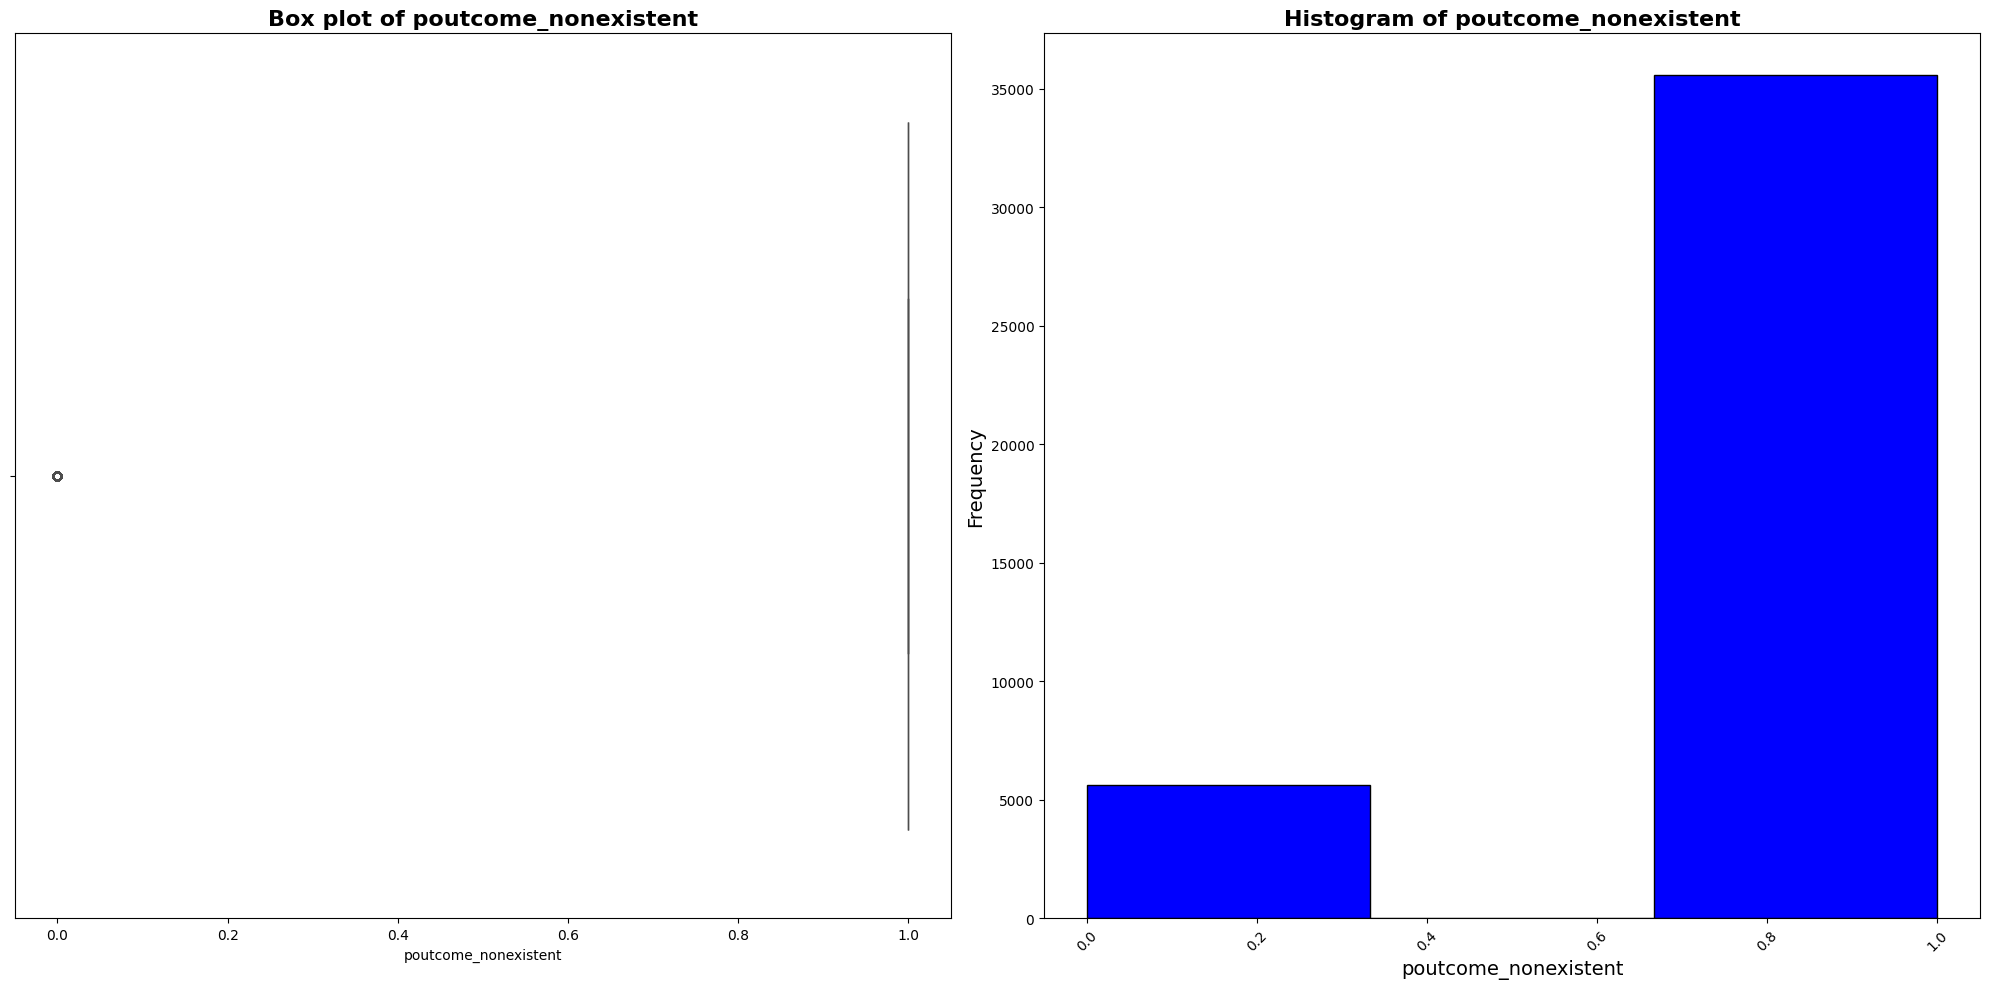

In [44]:
bank_df['poutcome_nonexistent'] = (bank_df['poutcome'] == 'nonexistent').astype(int)

HelperFunctions.show_numeric_info(bank_df, 'poutcome_nonexistent', 3)

***16. `emp.var.rate` column analysis***


count    41176.000000
mean         0.081922
std          1.570883
min         -3.400000
25%         -1.800000
50%          1.100000
75%          1.400000
max          1.400000
Name: emp.var.rate, dtype: float64
Number of null values: 0


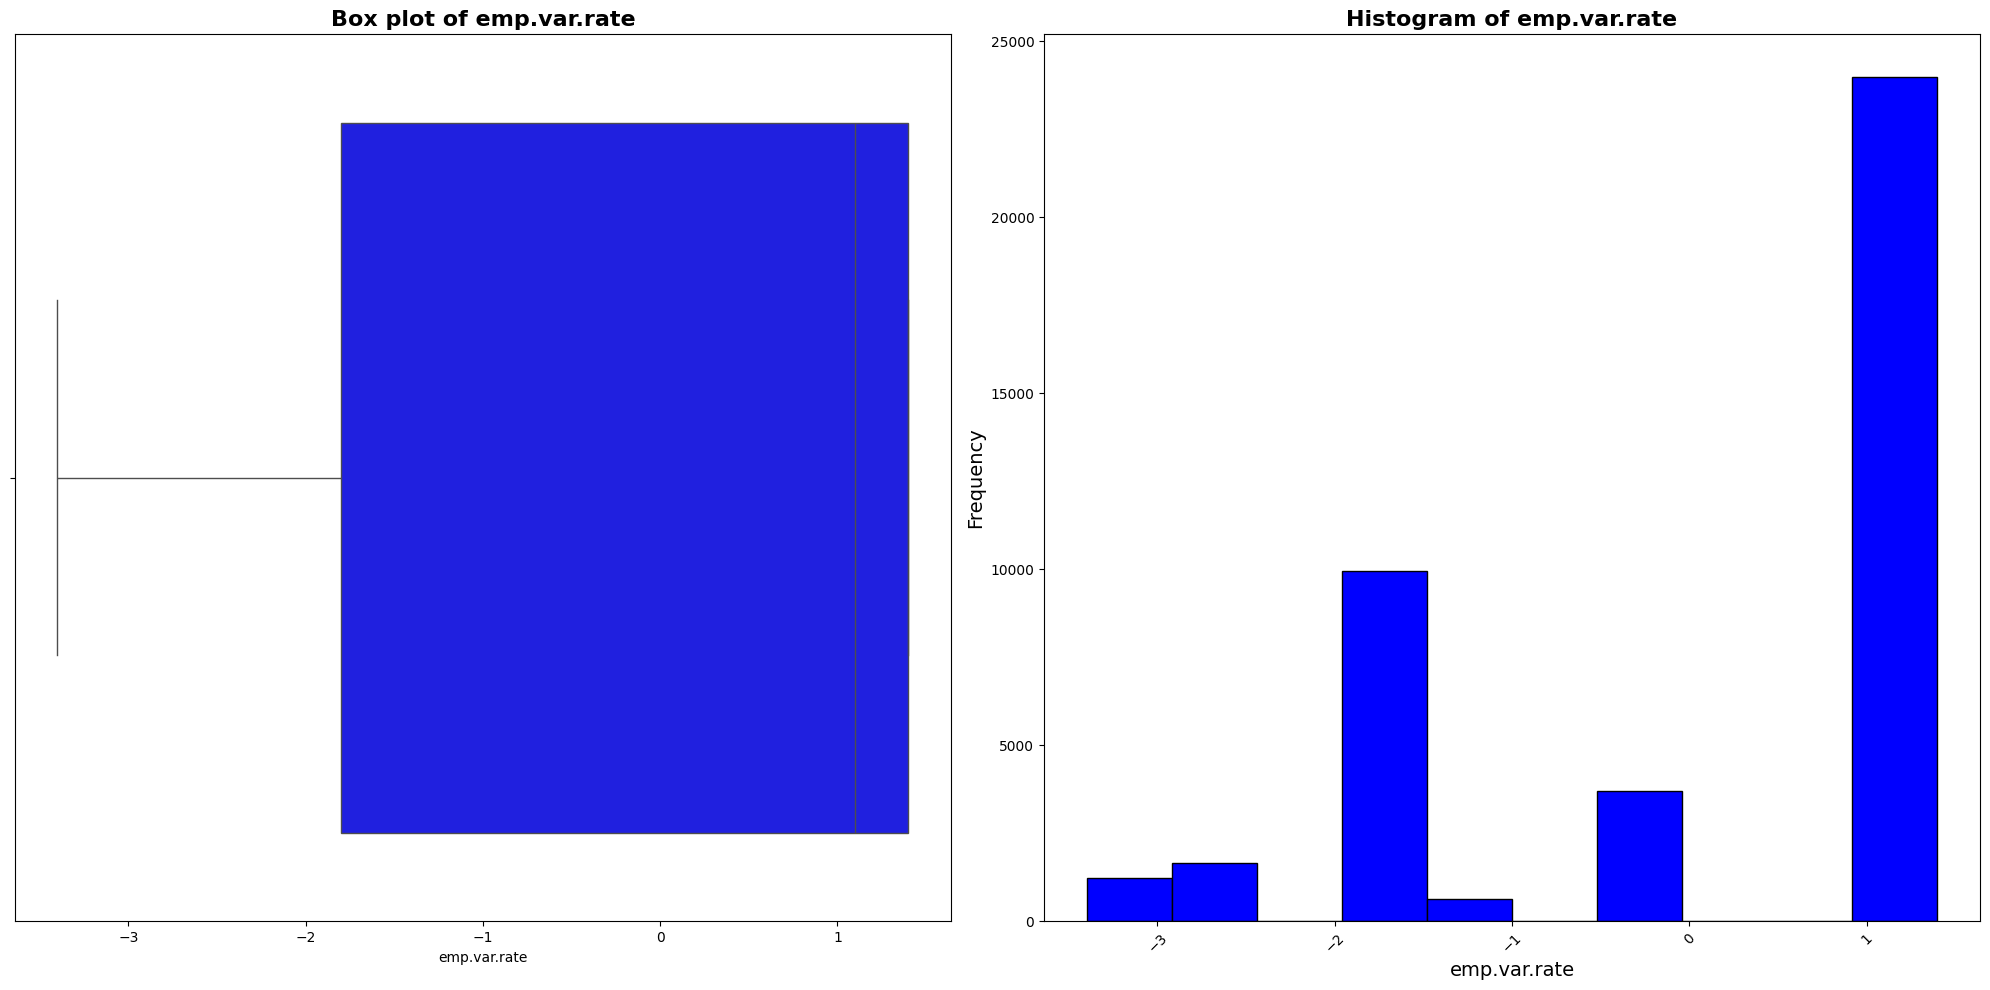

In [46]:
HelperFunctions.show_numeric_info(bank_df, 'emp.var.rate', 10)

Just log transform will be enough here

count    27682.000000
mean         0.707169
std          0.324152
min         -0.223144
25%          0.741937
50%          0.875469
75%          0.875469
max          0.875469
Name: emp.var.rate_log, dtype: float64
Number of null values: 13494


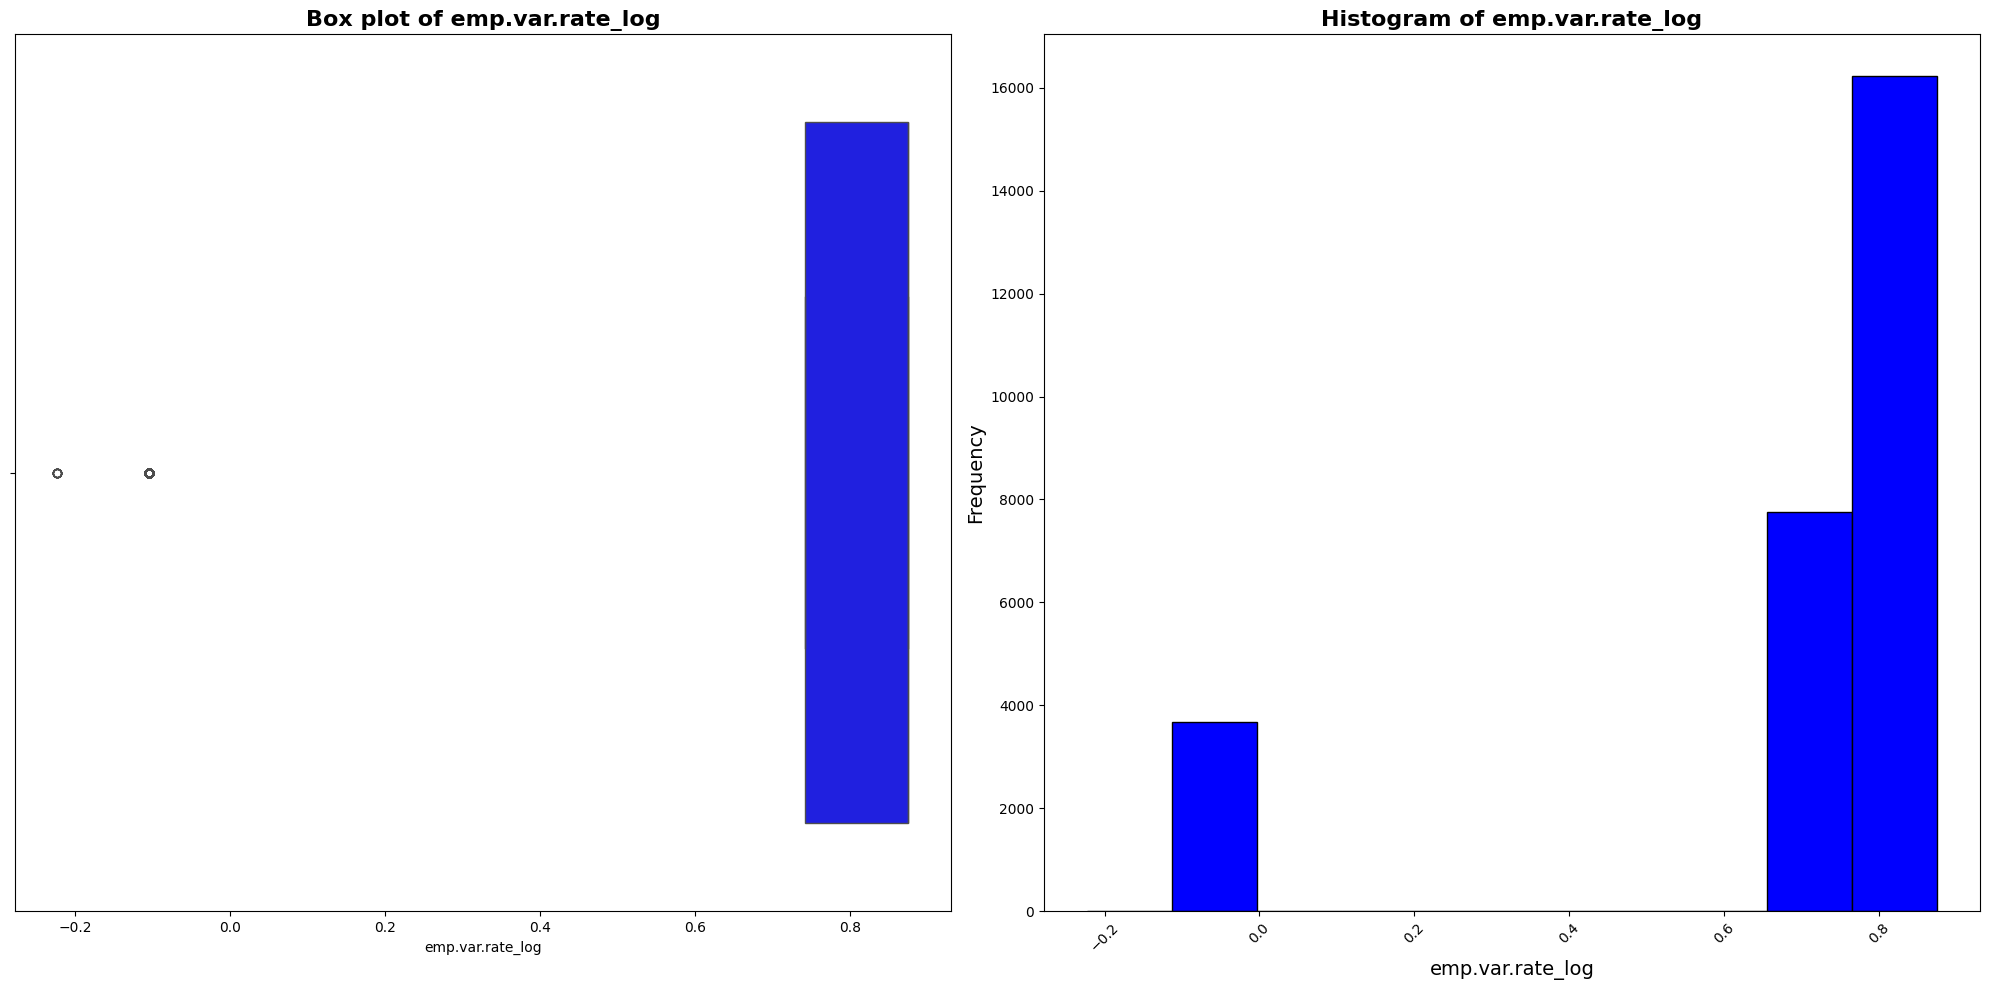

In [47]:
bank_df["emp.var.rate_log"] = np.log1p(bank_df["emp.var.rate"])

HelperFunctions.show_numeric_info(bank_df, 'emp.var.rate_log', 10)

***17. `cons.price.idx` column analysis***

count    41176.000000
mean        93.575720
std          0.578839
min         92.201000
25%         93.075000
50%         93.749000
75%         93.994000
max         94.767000
Name: cons.price.idx, dtype: float64
Number of null values: 0


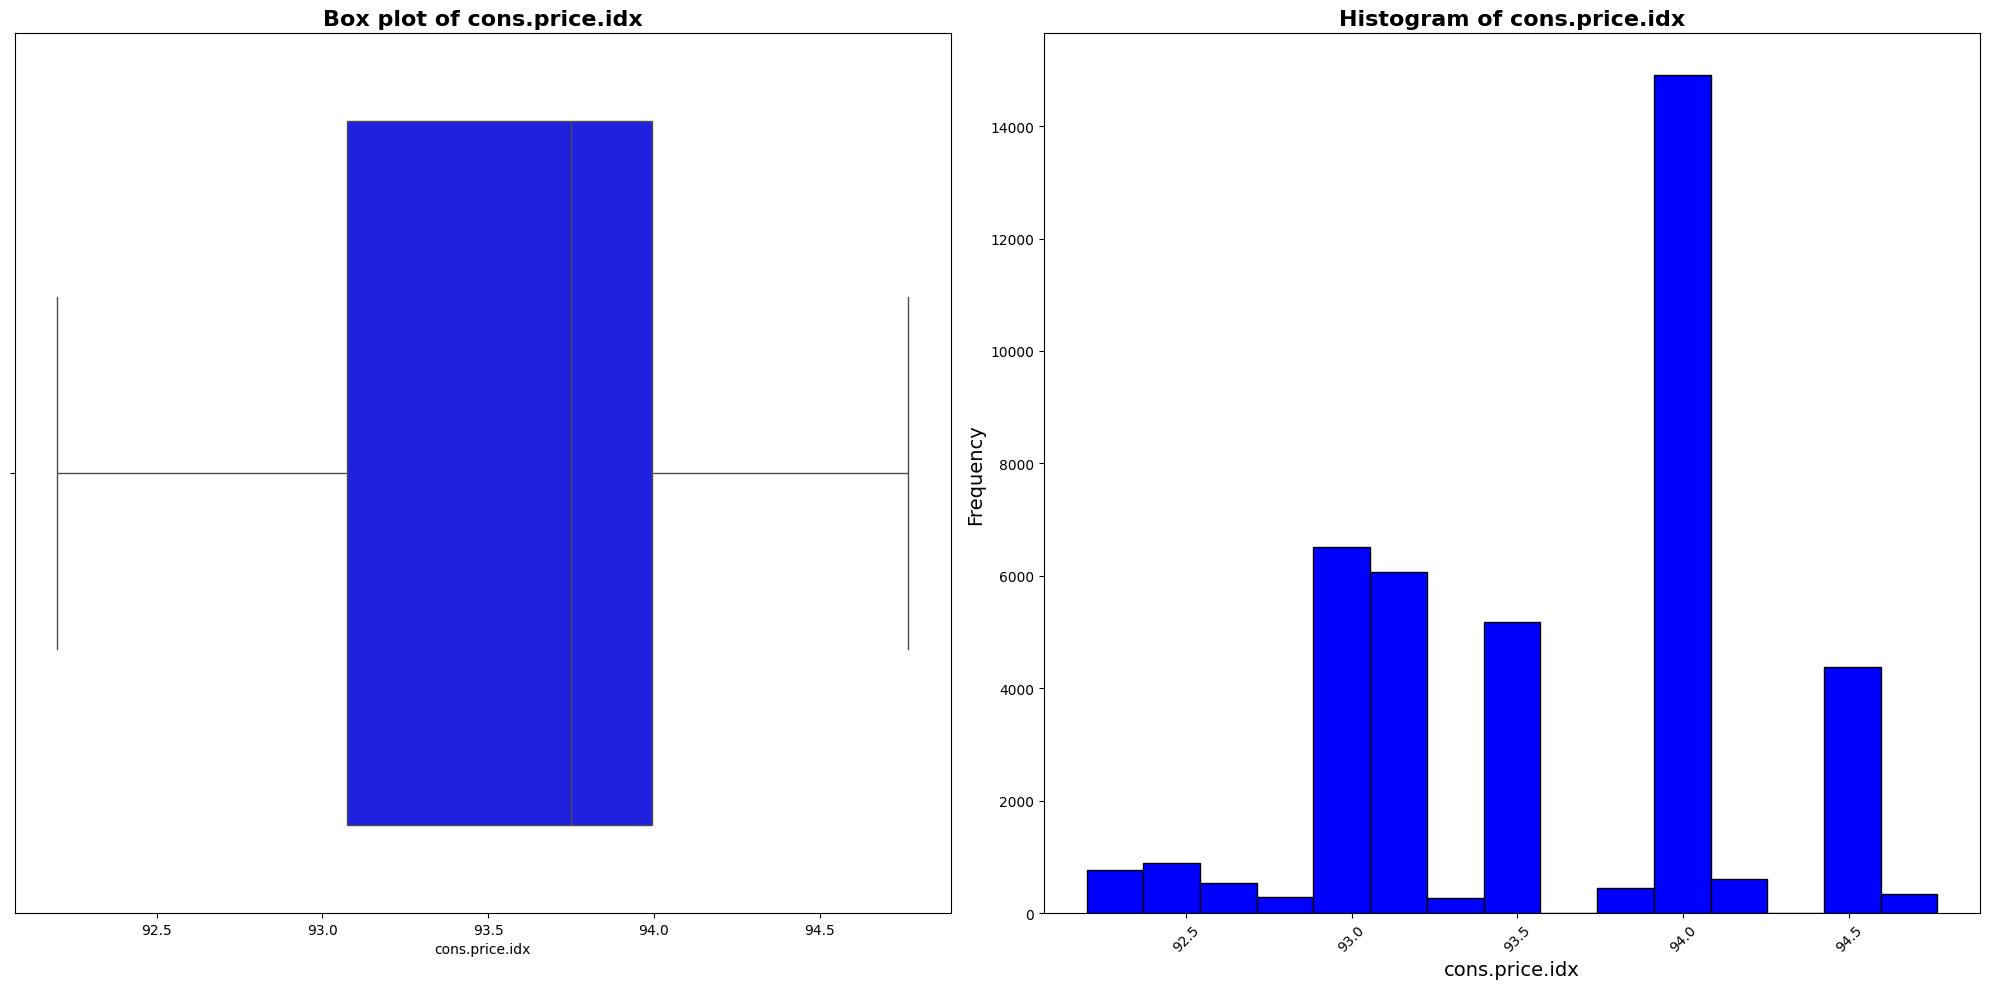

In [50]:
HelperFunctions.show_numeric_info(bank_df, 'cons.price.idx', 15)

No imputations are required here.

***18. `cons.conf.idx` column analysis***

count    41176.000000
mean       -40.502863
std          4.627860
min        -50.800000
25%        -42.700000
50%        -41.800000
75%        -36.400000
max        -26.900000
Name: cons.conf.idx, dtype: float64
Number of null values: 0


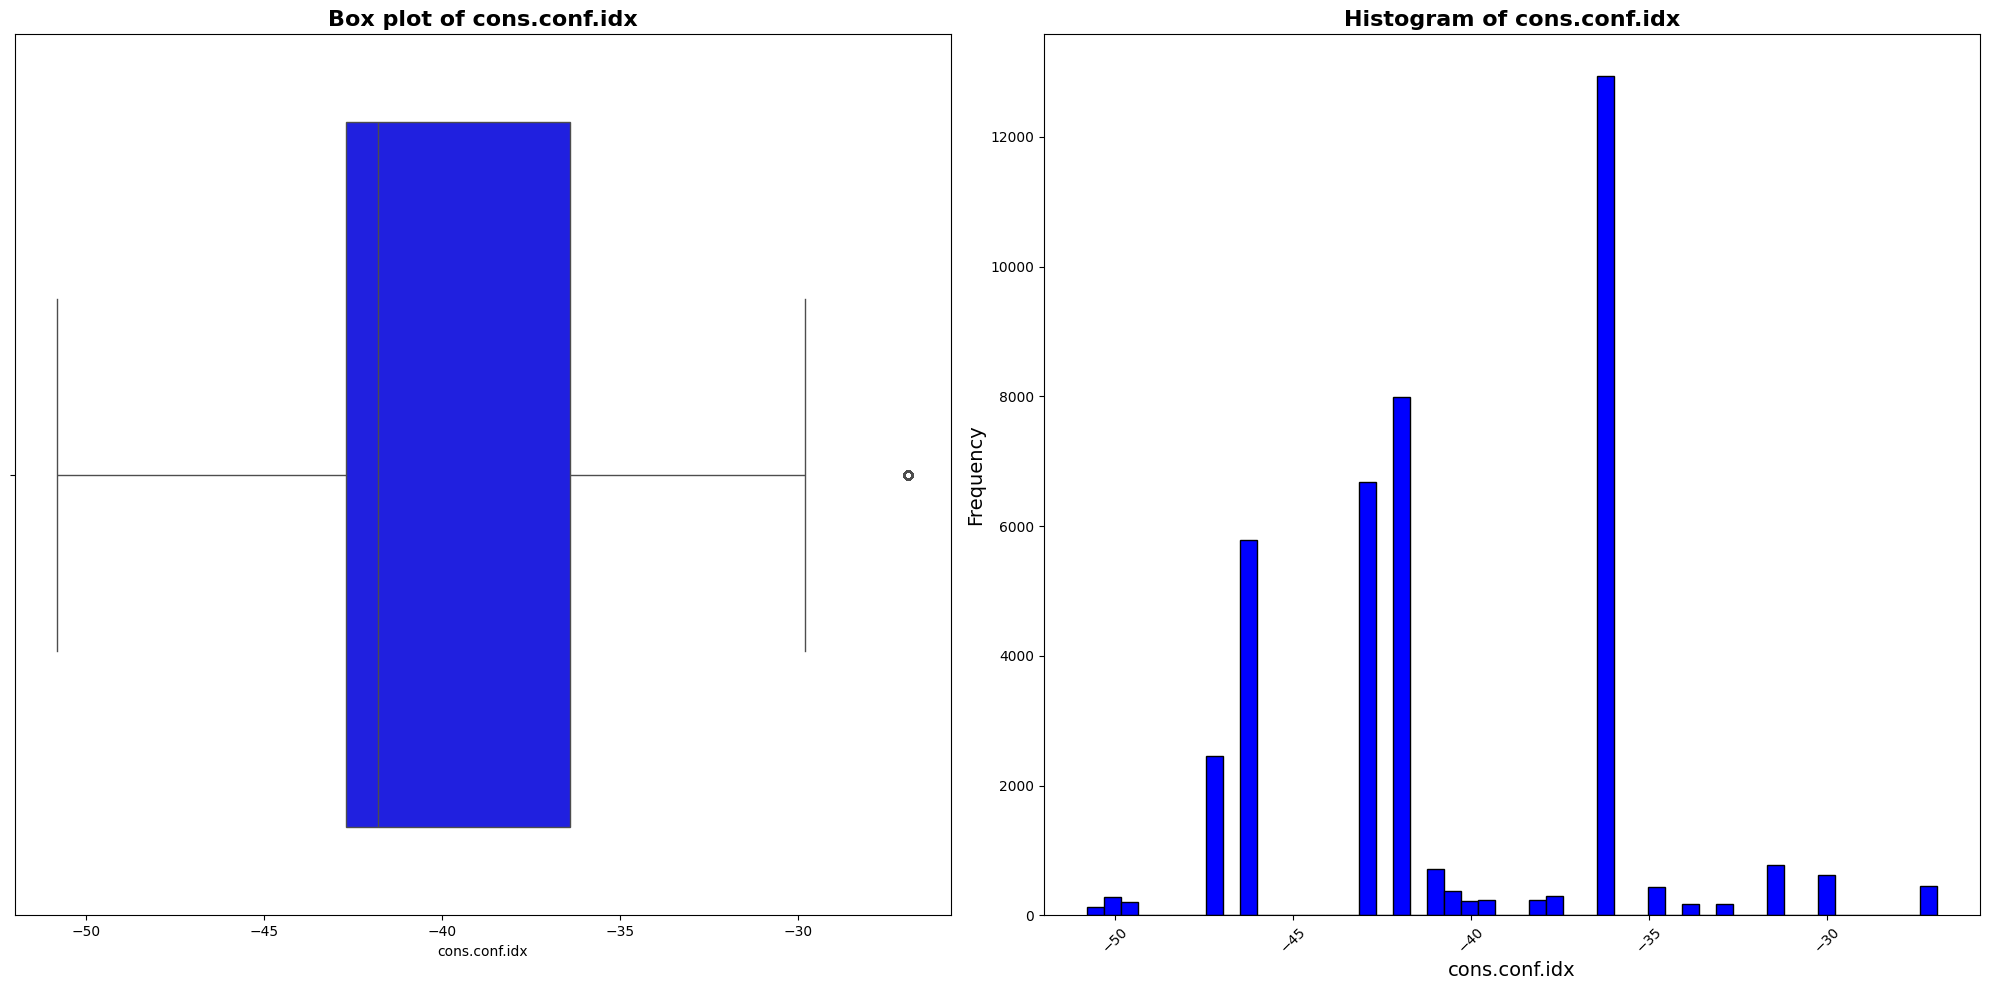

In [52]:
HelperFunctions.show_numeric_info(bank_df, 'cons.conf.idx', 50)

No imputations are required here.

***19. `euribor3m` column analysis***

count    41176.000000
mean         3.621293
std          1.734437
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64
Number of null values: 0


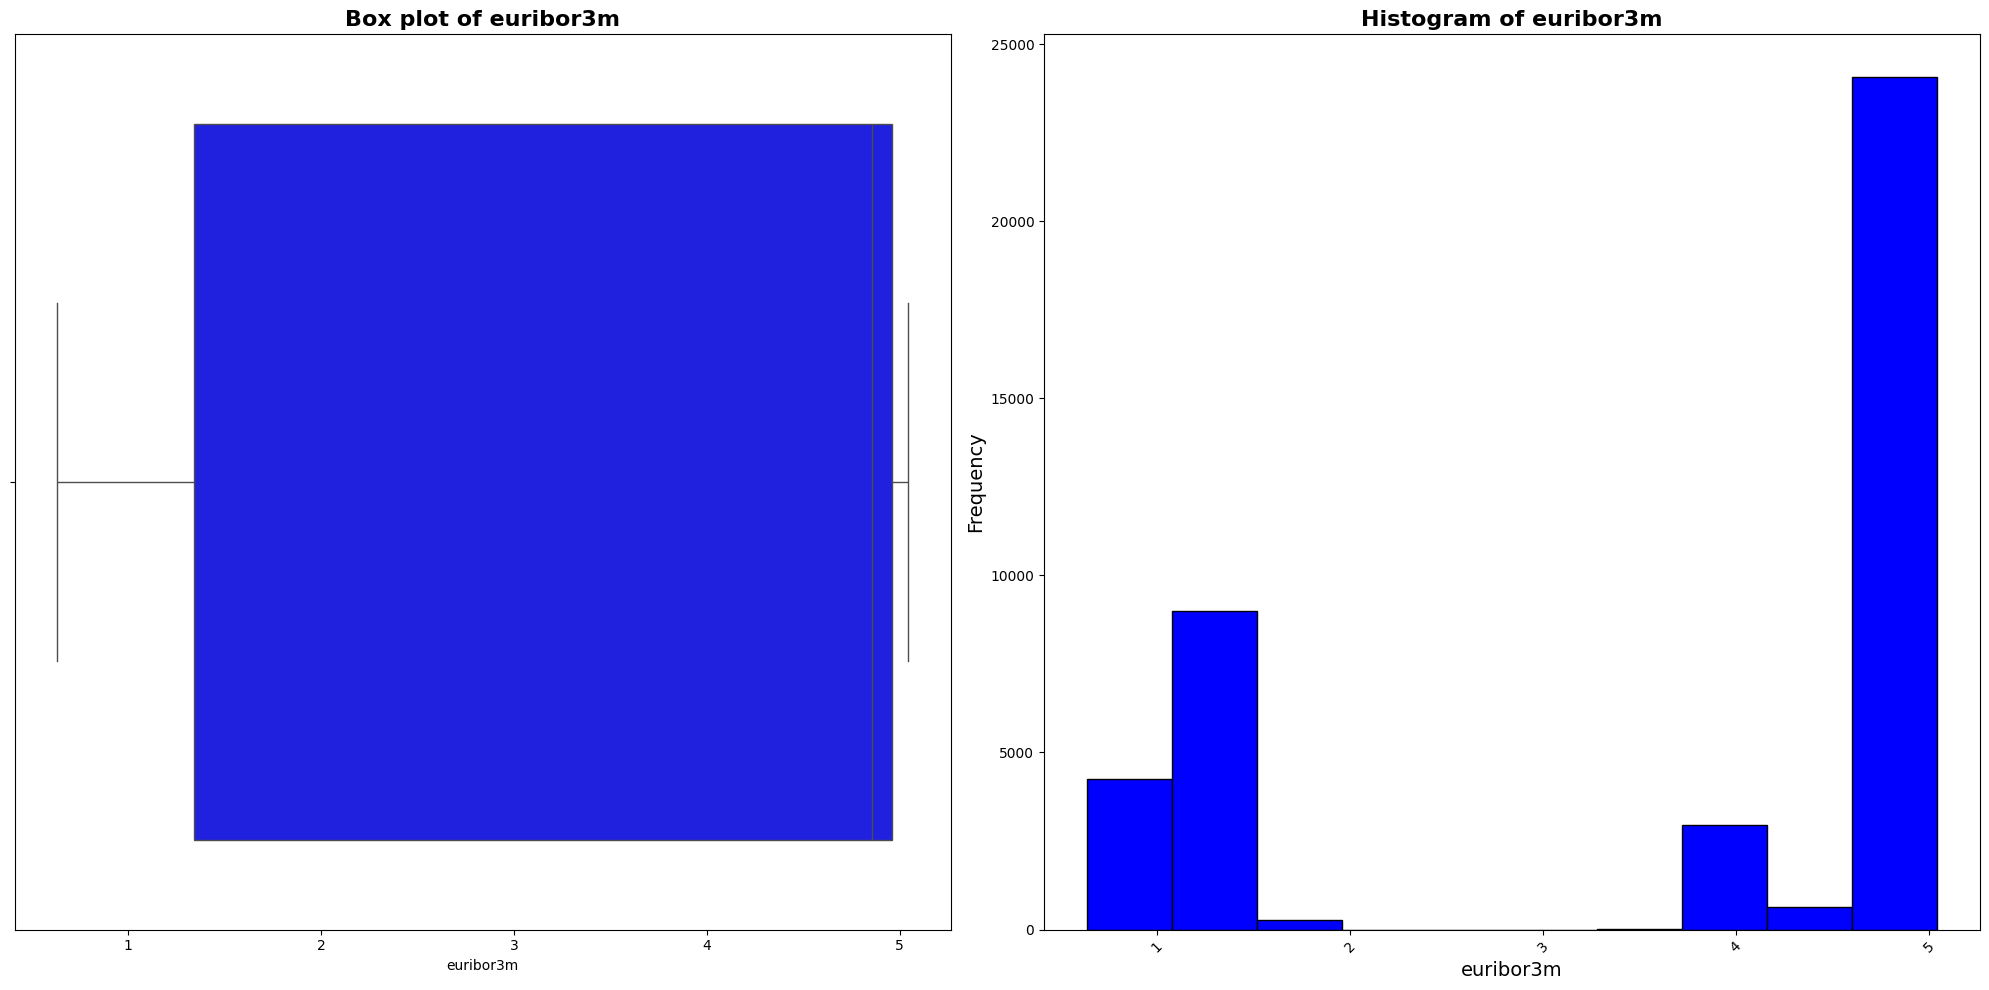

In [55]:
HelperFunctions.show_numeric_info(bank_df, 'euribor3m', 10)

No imputations are required here.

***20. `nr.employed` column analysis***

count    41176.000000
mean      5167.034870
std         72.251364
min       4963.600000
25%       5099.100000
50%       5191.000000
75%       5228.100000
max       5228.100000
Name: nr.employed, dtype: float64
Number of null values: 0


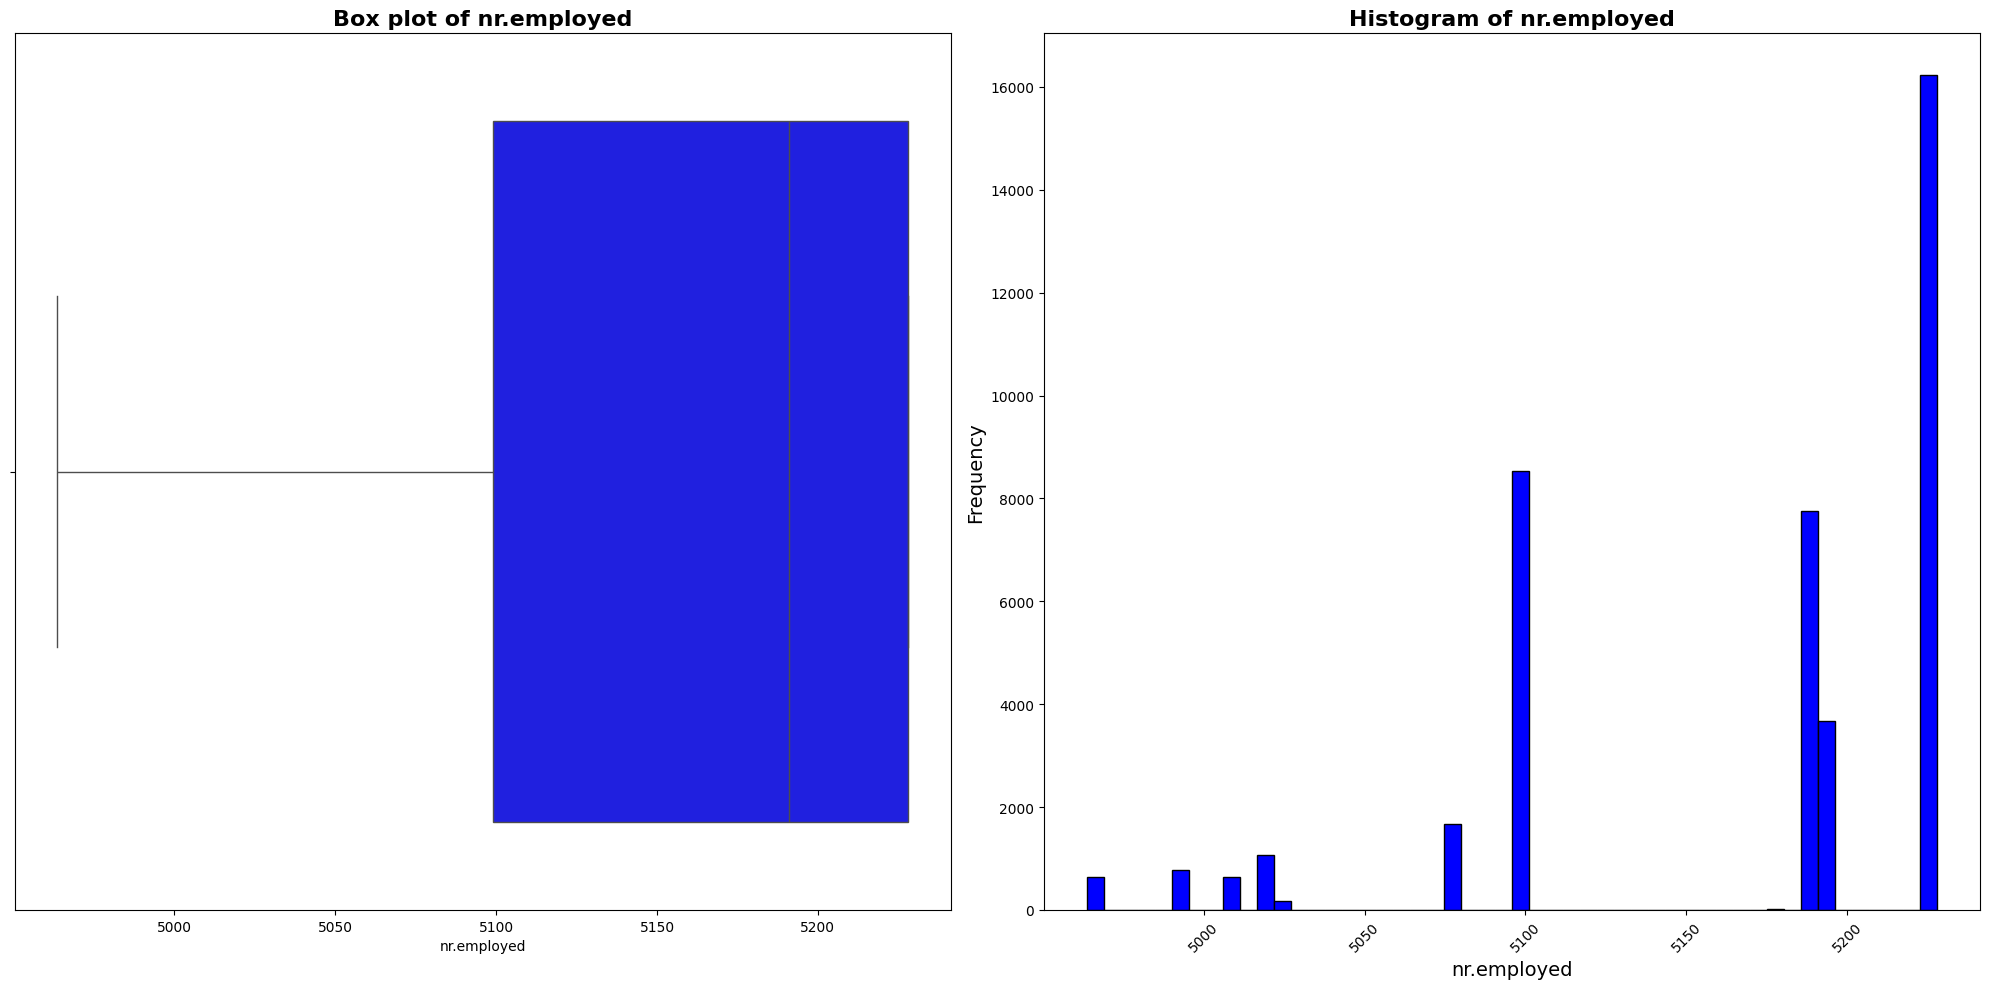

In [56]:
HelperFunctions.show_numeric_info(bank_df, 'nr.employed', 50)

No imputations are required here.

***21. `y` column analysis***

count     41176
unique        2
top          no
freq      36537
Name: y, dtype: object
Number of null values: 0


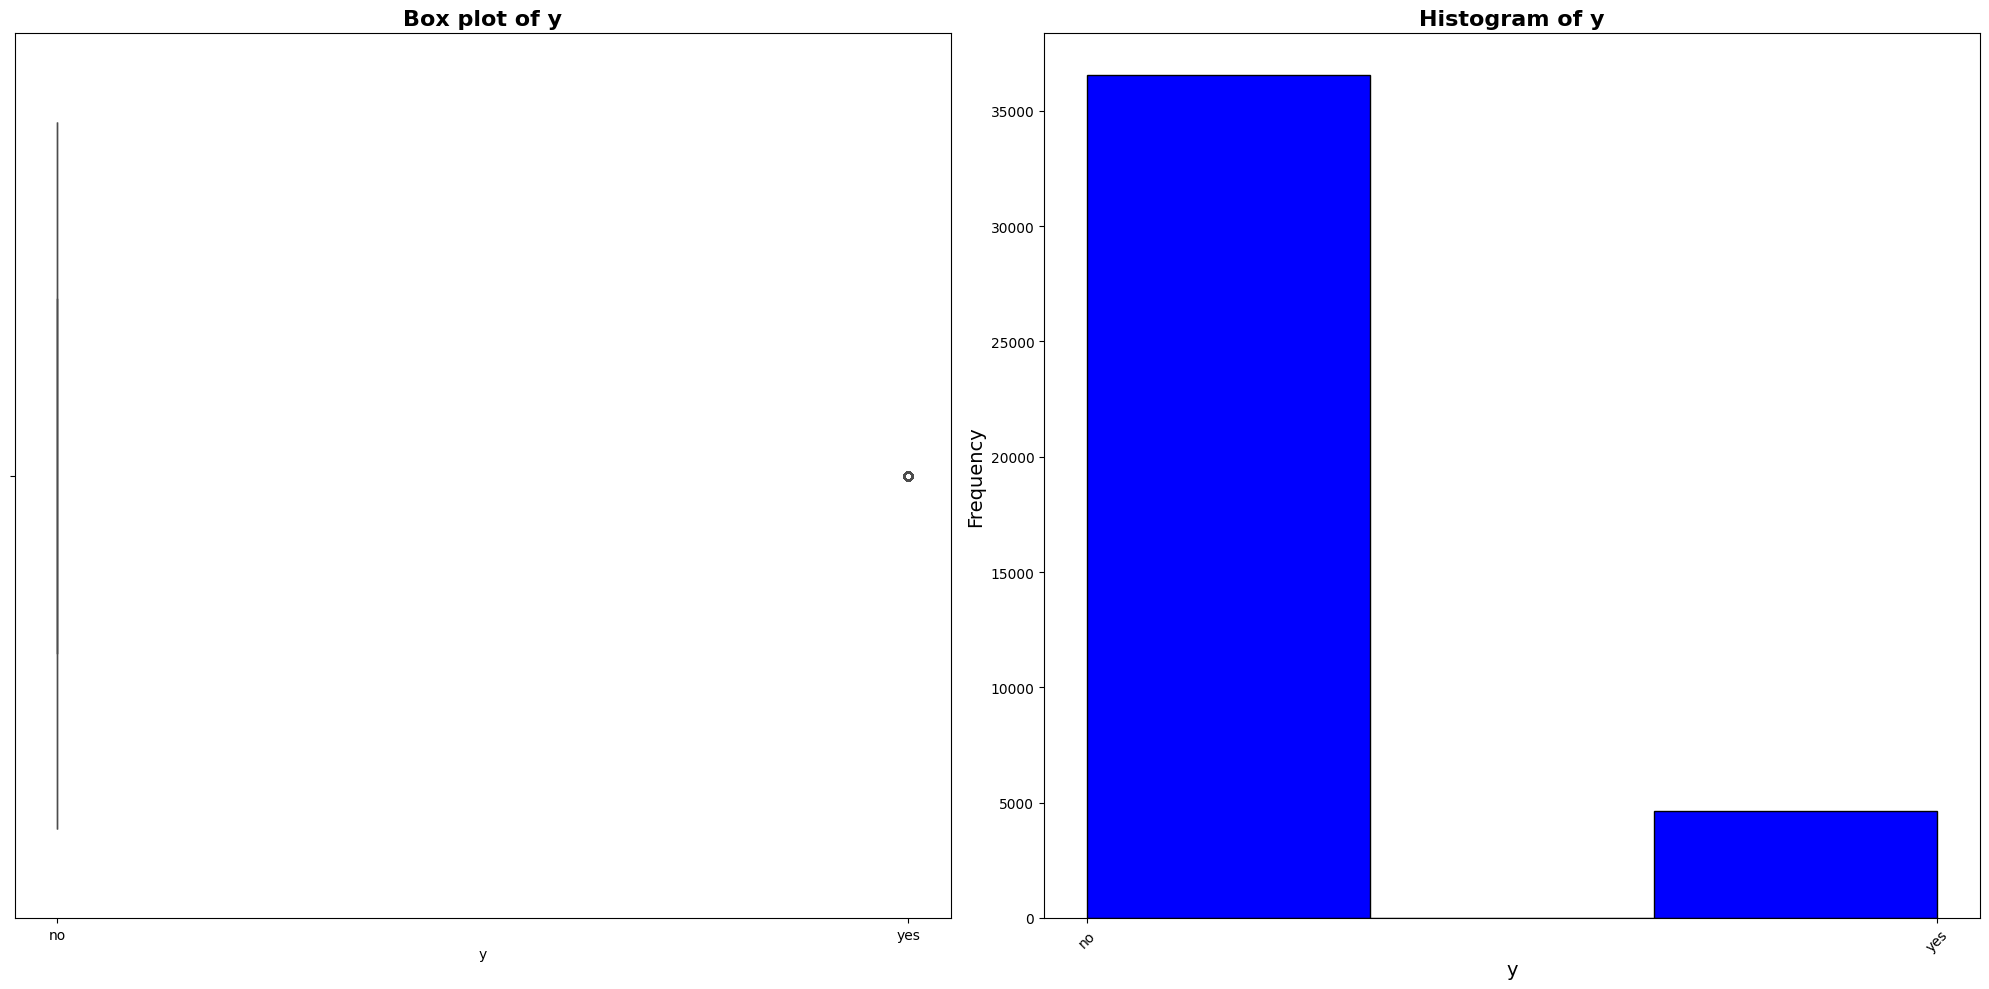

In [57]:
HelperFunctions.show_numeric_info(bank_df, 'y', 3)

### Deside which metrics to use

As we can see from our target column, it is highly imballanced, so i will use such metrics to evaluate my models:

- **F1-Score**. It is applicable for imbalanced datasets and can be used for all 4 types of models.
- **ROC-AUC***. It also works good with imbalanced data and can show model ability to separate classes.
- **Precision ROC-AUC (PR-AUC)**. It should be even better suitable for imbalanced classes and it mainly focuses on positive classes.
- **Geometric Mean (G-Mean)**. It ensures that model performs good on both classes.